In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (14,7)
plt.rcParams["font.size"] = 12

In [2]:
DATA_DIR = "/home/yousef/Documents/testing_scripts/GEVernova/Fi_Wo_Ca_Dy/Dynamic/Dyn_Files/b200_dynamic_range_max_pulses_BigRange/"

RAW_CSV = DATA_DIR + "dynamic_range_max_raw_measurements.csv"
POINTS_CSV = DATA_DIR + "dynamic_range_max_aggregated_points.csv"
SUMMARY_CSV = DATA_DIR + "dynamic_range_max_summary.csv"

raw_df = pd.read_csv(RAW_CSV)
points_df = pd.read_csv(POINTS_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)

In [3]:
print(raw_df.shape)
print(points_df.shape)
print(summary_df.shape)

display(points_df.head())
display(summary_df.head())

(216300, 20)
(18300, 19)
(300, 15)


,frequency_hz,frequency_mhz,gain_db,input_rx2_dbm,generator_dbm,attenuation_db,max_dbfs,robust_dbfs,median_dbfs,noise_max_dbfs,noise_robust_dbfs,median_max_excess_db,median_robust_excess_db,detection_probability,peak_amplitude,clipping_fraction,predicted_max_dbfs,compression_db,linear
0,80000000.0,80.0,0.0,-80.0,-20.0,60.0,-60.151060,-61.577888,-72.719319,-60.347965,-61.729892,0.196905,0.152004,0.0,0.001009,0.0,-80.189864,-20.038805,False
1,80000000.0,80.0,0.0,-79.0,-19.0,60.0,-60.332752,-61.409003,-72.678386,-60.347965,-61.729892,0.015213,0.320890,0.0,0.001032,0.0,-79.274711,-18.941959,False
2,80000000.0,80.0,0.0,-78.0,-18.0,60.0,-59.945999,-61.425742,-72.614094,-60.347965,-61.729892,0.401966,0.304150,0.0,0.001055,0.0,-78.359557,-18.413558,False
3,80000000.0,80.0,0.0,-77.0,-17.0,60.0,-60.110162,-61.389527,-72.519935,-60.347965,-61.729892,0.237803,0.340365,0.0,0.001034,0.0,-77.444403,-17.334241,False
4,80000000.0,80.0,0.0,-76.0,-16.0,60.0,-59.872916,-61.365948,-72.399731,-60.347965,-61.729892,0.475049,0.363944,0.0,0.001048,0.0,-76.529250,-16.656334,False


,frequency_hz,frequency_mhz,gain_db,rx2_min_tested_dbm,rx2_max_tested_dbm,noise_max_dbfs,noise_robust_dbfs,minimum_detectable_dbm,pmin_status,maximum_linear_dbm,pmax_status,dynamic_range_db,linear_fit_slope,linear_fit_intercept,number_of_input_points
0,80000000.0,80.0,0.0,-80.0,-20.0,-60.254124,-61.719299,-52.0,mesure_valide,-20.0,limite_haute_du_banc,32.0,0.915154,-6.977567,61
1,80000000.0,80.0,20.0,-80.0,-20.0,-55.498656,-56.923574,-69.0,mesure_valide,-20.0,limite_haute_du_banc,49.0,0.941599,10.986658,61
2,80000000.0,80.0,40.0,-80.0,-20.0,-50.421157,-52.020938,-80.0,limite_basse_du_banc,-44.0,mesure_valide,36.0,0.870451,28.356413,61
3,80000000.0,80.0,60.0,-80.0,-20.0,-35.204683,-36.548095,-80.0,limite_basse_du_banc,-54.0,mesure_valide,26.0,0.875807,45.525638,61
4,80000000.0,80.0,76.0,-80.0,-20.0,-22.893047,-24.174382,-80.0,limite_basse_du_banc,NaN,aucun_point_lineaire,NaN,NaN,NaN,61


In [4]:
GAIN = 0

gain_points = points_df[
    points_df["gain_db"] == GAIN
].copy()

gain_summary = summary_df[
    summary_df["gain_db"] == GAIN
].copy()

gain_points = gain_points.sort_values(
    ["input_rx2_dbm","frequency_mhz"]
)

gain_summary = gain_summary.sort_values(
    "frequency_mhz"
)

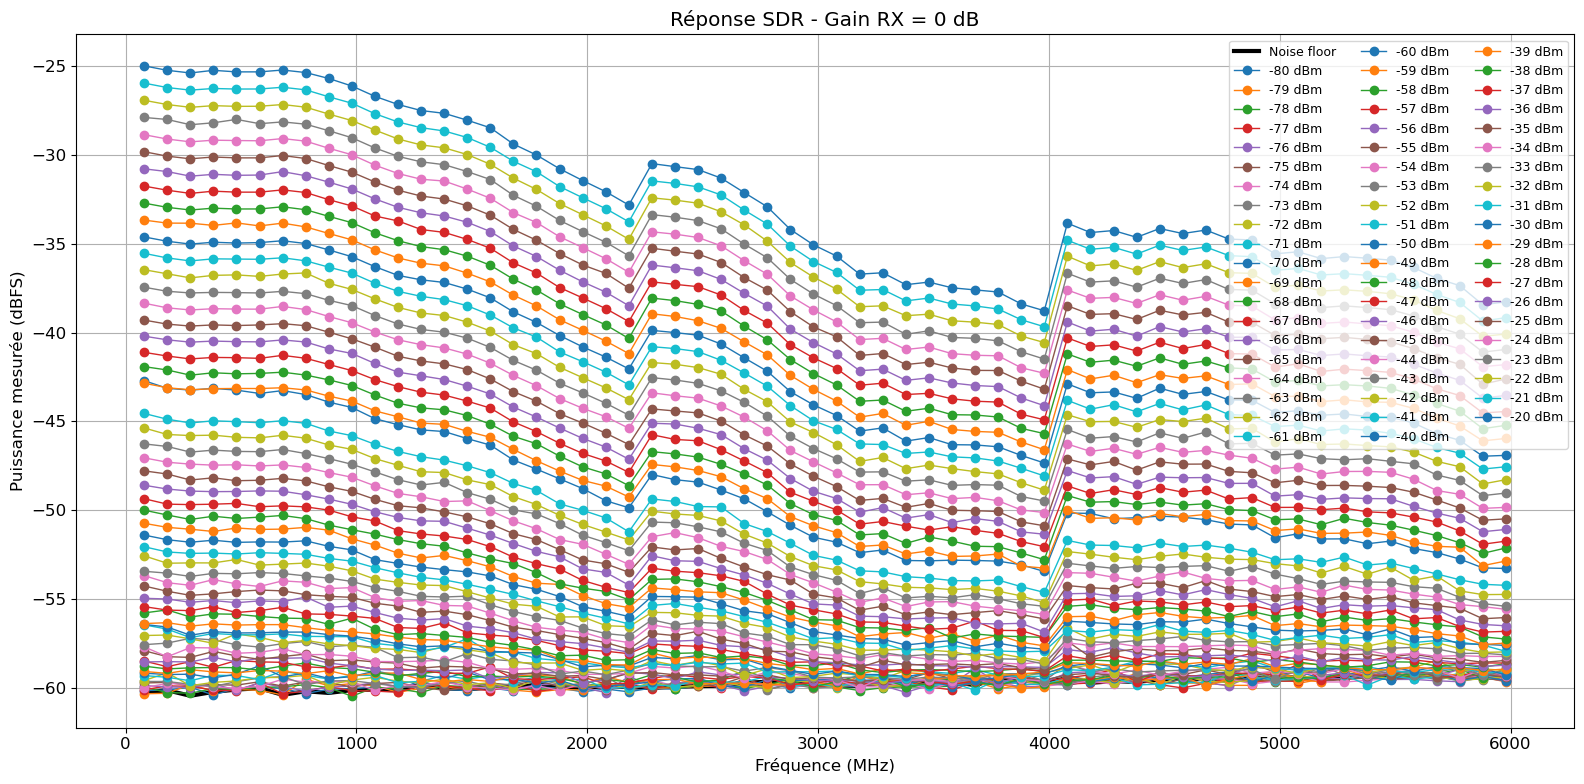

In [5]:
plt.figure(figsize=(16,8))

##########################################
# Noise floor
##########################################

plt.plot(
    gain_summary["frequency_mhz"],
    gain_summary["noise_max_dbfs"],
    color="black",
    linewidth=3,
    label="Noise floor"
)

##########################################
# Toutes les puissances injectées
##########################################

levels = sorted(
    gain_points["input_rx2_dbm"].unique()
)

for level in levels:

    df = gain_points[
        gain_points["input_rx2_dbm"] == level
    ]

    plt.plot(
        df["frequency_mhz"],
        df["max_dbfs"],
        marker="o",
        linewidth=1,
        markersize=6,
        label=f"{level:.0f} dBm"
    )

plt.title(f"Réponse SDR - Gain RX = {GAIN} dB")

plt.xlabel("Fréquence (MHz)")
plt.ylabel("Puissance mesurée (dBFS)")

plt.grid(True)

plt.legend(
    ncol=3,
    fontsize=9
)

plt.tight_layout()
plt.show()

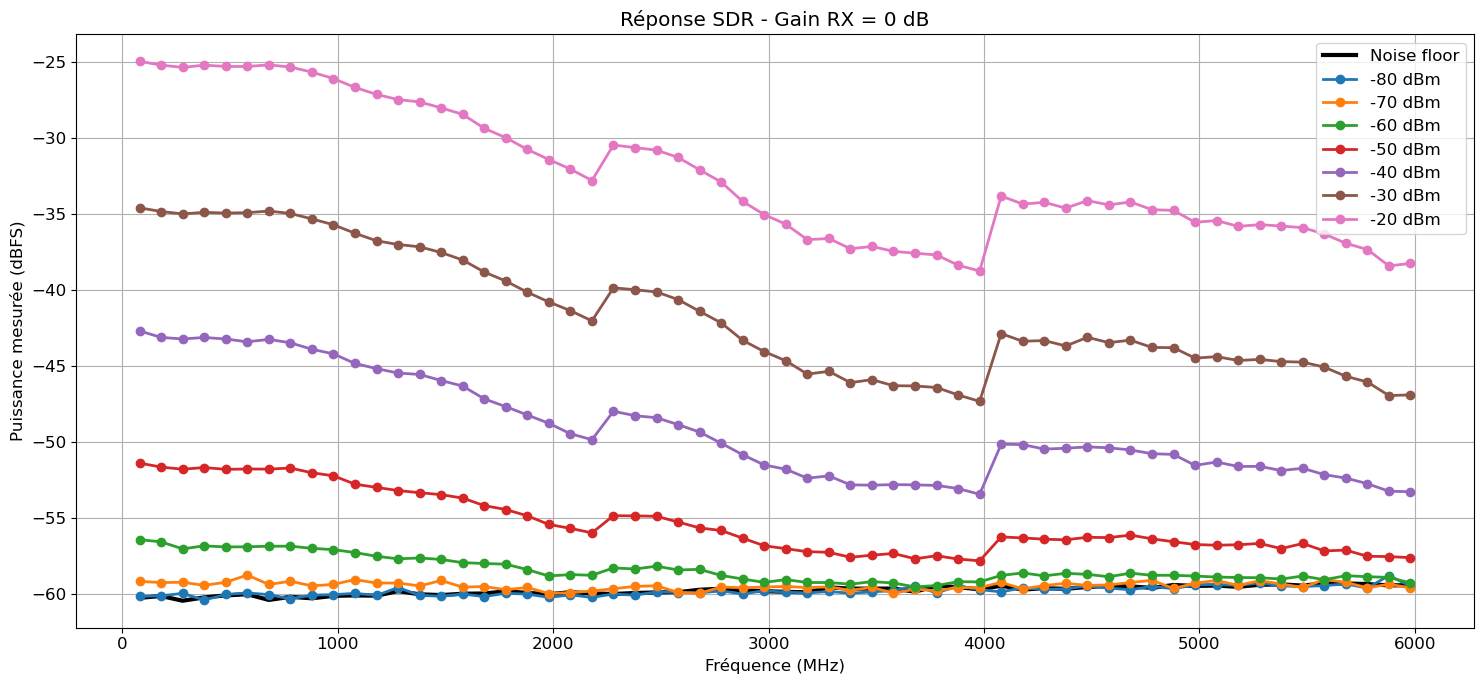

In [6]:
DISPLAY_LEVELS = [
    -80,
    -70,
    -60,
    -50,
    -40,
    -30,
    -20
]

plt.figure(figsize=(15,7))

plt.plot(
    gain_summary["frequency_mhz"],
    gain_summary["noise_max_dbfs"],
    color="black",
    linewidth=3,
    label="Noise floor"
)

for level in DISPLAY_LEVELS:

    df = gain_points[
        np.isclose(
            gain_points["input_rx2_dbm"],
            level
        )
    ]

    if len(df)==0:
        continue

    plt.plot(
        df["frequency_mhz"],
        df["max_dbfs"],
        marker="o",
        linewidth=2,
        label=f"{level} dBm"
    )

plt.title(f"Réponse SDR - Gain RX = {GAIN} dB")

plt.xlabel("Fréquence (MHz)")
plt.ylabel("Puissance mesurée (dBFS)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
gain_summary[
[
    "frequency_mhz",
    "minimum_detectable_dbm",
    "maximum_linear_dbm",
    "dynamic_range_db"
]
]

,frequency_mhz,minimum_detectable_dbm,maximum_linear_dbm,dynamic_range_db
0,80.0,-52.0,-20.0,32.0
5,180.0,-52.0,-20.0,32.0
10,280.0,-53.0,-20.0,33.0
15,380.0,-52.0,-20.0,32.0
20,480.0,-52.0,-20.0,32.0
25,580.0,-52.0,-20.0,32.0
30,680.0,-53.0,-20.0,33.0
35,780.0,-52.0,-20.0,32.0
40,880.0,-52.0,-20.0,32.0
45,980.0,-51.0,-20.0,31.0


Calibration chargée : /home/yousef/b200_calibration_results/rx2_complete_100MHz_2GHz.pickle
Plage de fréquences : 100.0 MHz à 2000.0 MHz
Gains disponibles : [0.0, 20.0, 40.0, 60.0, 76.0]

Exemple de conversion des points :
 frequency_mhz  input_rx2_dbm   max_dbfs  calibration_reference_db    max_dbm
         100.0          -80.0 -10.544521                -66.875878 -77.420399
         200.0          -80.0 -10.194811                -67.534395 -77.729206
         300.0          -80.0 -10.010701                -67.615310 -77.626012
         400.0          -80.0  -9.966581                -67.851344 -77.817925
         500.0          -80.0  -8.907983                -67.888858 -76.796841
         600.0          -80.0 -10.055415                -67.689627 -77.745042
         700.0          -80.0  -9.943963                -67.878416 -77.822379
         800.0          -80.0  -9.506178                -67.901922 -77.408101
         900.0          -80.0 -10.207408                -67.534483 -77.7418

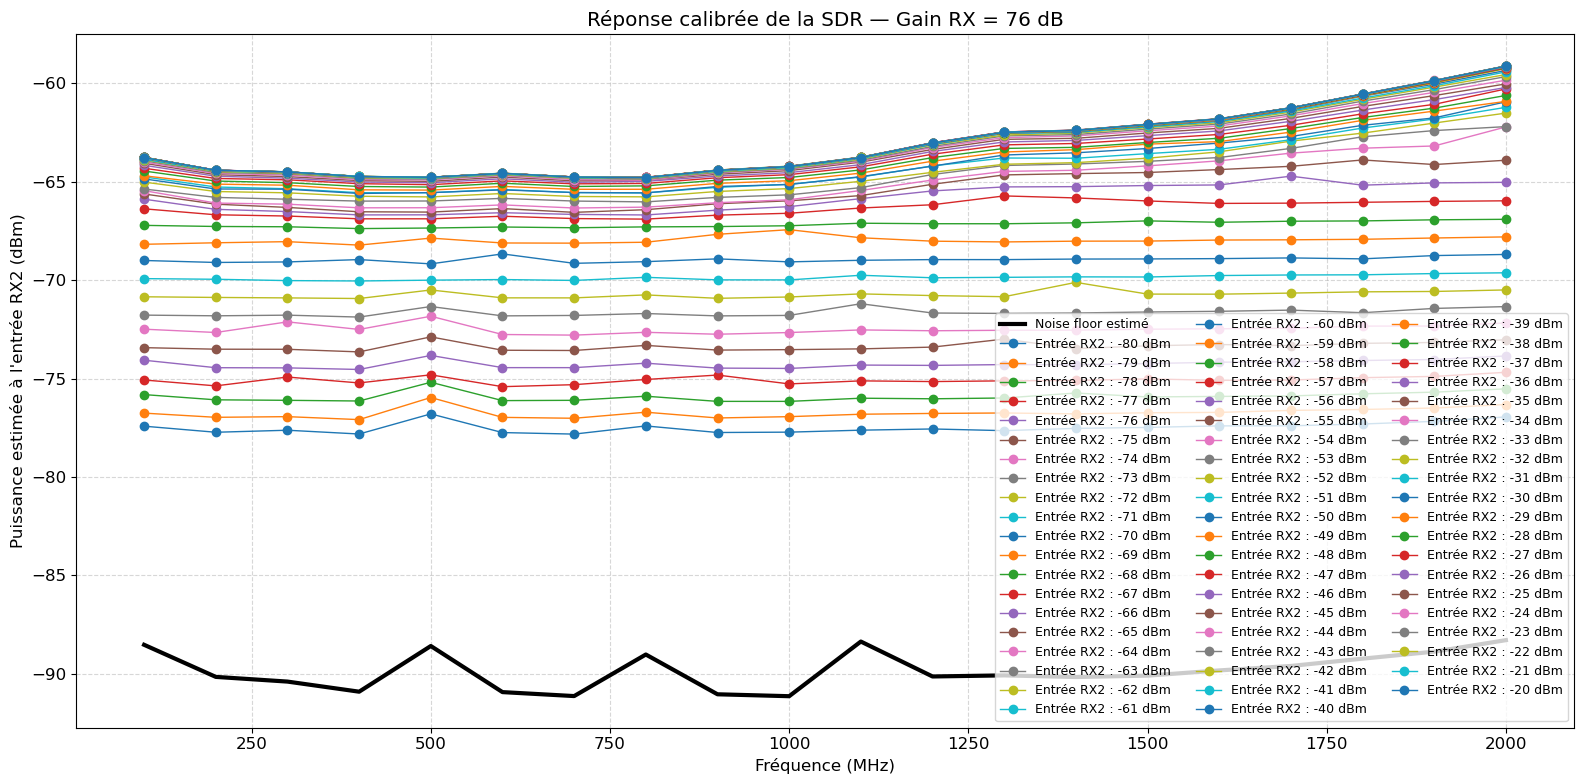

In [8]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# CONFIGURATION
# ============================================================

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["font.size"] = 12

DATA_DIR = Path("/home/yousef/b200_dynamic_range_max_pulses")

RAW_CSV = DATA_DIR / "dynamic_range_max_raw_measurements.csv"
POINTS_CSV = DATA_DIR / "dynamic_range_max_aggregated_points.csv"
SUMMARY_CSV = DATA_DIR / "dynamic_range_max_summary.csv"

CAL_FILE = (
    Path.home()
    / "b200_calibration_results"
    / "rx2_complete_100MHz_2GHz.pickle"
)

GAIN = 76.0


# ============================================================
# CHARGEMENT DES CSV
# ============================================================

for csv_file in [RAW_CSV, POINTS_CSV, SUMMARY_CSV]:
    if not csv_file.exists():
        raise FileNotFoundError(
            f"Fichier CSV introuvable : {csv_file.resolve()}"
        )

raw_df = pd.read_csv(RAW_CSV)
points_df = pd.read_csv(POINTS_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)


# ============================================================
# CHARGEMENT DE LA CALIBRATION RX2
# ============================================================

def load_calibration(
    path: Path,
) -> dict[float, dict[float, float]]:
    """
    Charge la calibration sous la forme :

    calibration[frequency_hz][gain_db] = reference_db
    """

    if not path.exists():
        raise FileNotFoundError(
            f"Fichier de calibration introuvable : {path}"
        )

    with path.open("rb") as file:
        raw_calibration = pickle.load(file)

    try:
        rx2_table = raw_calibration[0]["RX2"]
    except (KeyError, IndexError, TypeError) as error:
        raise RuntimeError(
            "Structure inattendue dans le fichier de calibration. "
            'La structure attendue est raw[0]["RX2"].'
        ) from error

    calibration = {
        float(frequency_hz): {
            float(gain_db): float(reference_db)
            for gain_db, reference_db in gain_table.items()
        }
        for frequency_hz, gain_table in rx2_table.items()
    }

    if not calibration:
        raise RuntimeError(
            "La table de calibration RX2 est vide."
        )

    return calibration


# ============================================================
# INTERPOLATION SELON LA FRÉQUENCE
# ============================================================

def reference_at_frequency(
    calibration: dict[float, dict[float, float]],
    frequency_hz: float,
    calibrated_gain_db: float,
) -> float:
    """
    Retourne la référence de calibration pour une fréquence
    et un gain calibré.

    Une interpolation linéaire est effectuée entre les
    fréquences disponibles.
    """

    calibration_points = []

    for calibrated_frequency_hz, gain_table in calibration.items():
        matching_gain = None

        for available_gain_db in gain_table:
            if np.isclose(
                available_gain_db,
                calibrated_gain_db,
                atol=1e-6,
            ):
                matching_gain = available_gain_db
                break

        if matching_gain is not None:
            calibration_points.append(
                (
                    float(calibrated_frequency_hz),
                    float(gain_table[matching_gain]),
                )
            )

    if not calibration_points:
        raise ValueError(
            f"Aucune calibration disponible pour le gain "
            f"{calibrated_gain_db:.1f} dB."
        )

    calibration_points.sort(key=lambda point: point[0])

    frequencies_hz = np.asarray(
        [point[0] for point in calibration_points],
        dtype=float,
    )

    references_db = np.asarray(
        [point[1] for point in calibration_points],
        dtype=float,
    )

    if frequency_hz < frequencies_hz[0]:
        raise ValueError(
            f"Fréquence {frequency_hz / 1e6:.1f} MHz inférieure "
            f"à la calibration minimale "
            f"{frequencies_hz[0] / 1e6:.1f} MHz."
        )

    if frequency_hz > frequencies_hz[-1]:
        raise ValueError(
            f"Fréquence {frequency_hz / 1e6:.1f} MHz supérieure "
            f"à la calibration maximale "
            f"{frequencies_hz[-1] / 1e6:.1f} MHz."
        )

    return float(
        np.interp(
            frequency_hz,
            frequencies_hz,
            references_db,
        )
    )


# ============================================================
# INTERPOLATION SELON LE GAIN
# ============================================================

def get_calibration_reference(
    calibration: dict[float, dict[float, float]],
    frequency_hz: float,
    gain_db: float,
) -> float:
    """
    Retourne C(f, G).

    Si le gain exact n'existe pas dans la calibration,
    une interpolation est effectuée entre les deux gains
    calibrés les plus proches.
    """

    available_gains = sorted(
        {
            float(calibrated_gain_db)
            for gain_table in calibration.values()
            for calibrated_gain_db in gain_table
        }
    )

    if not available_gains:
        raise RuntimeError(
            "Aucun gain trouvé dans la calibration."
        )

    if gain_db < available_gains[0]:
        raise ValueError(
            f"Gain {gain_db:.1f} dB inférieur au gain calibré minimal "
            f"{available_gains[0]:.1f} dB."
        )

    if gain_db > available_gains[-1]:
        raise ValueError(
            f"Gain {gain_db:.1f} dB supérieur au gain calibré maximal "
            f"{available_gains[-1]:.1f} dB."
        )

    # Gain exactement disponible
    for calibrated_gain_db in available_gains:
        if np.isclose(
            gain_db,
            calibrated_gain_db,
            atol=1e-6,
        ):
            return reference_at_frequency(
                calibration=calibration,
                frequency_hz=frequency_hz,
                calibrated_gain_db=calibrated_gain_db,
            )

    # Interpolation entre deux gains
    lower_gain_db = max(
        calibrated_gain_db
        for calibrated_gain_db in available_gains
        if calibrated_gain_db < gain_db
    )

    upper_gain_db = min(
        calibrated_gain_db
        for calibrated_gain_db in available_gains
        if calibrated_gain_db > gain_db
    )

    lower_reference_db = reference_at_frequency(
        calibration=calibration,
        frequency_hz=frequency_hz,
        calibrated_gain_db=lower_gain_db,
    )

    upper_reference_db = reference_at_frequency(
        calibration=calibration,
        frequency_hz=frequency_hz,
        calibrated_gain_db=upper_gain_db,
    )

    return float(
        np.interp(
            gain_db,
            [lower_gain_db, upper_gain_db],
            [lower_reference_db, upper_reference_db],
        )
    )


# ============================================================
# CONVERSION dBFS -> dBm
# ============================================================

def dbfs_to_dbm(
    measured_dbfs: float,
    frequency_mhz: float,
    gain_db: float,
    calibration: dict[float, dict[float, float]],
) -> float:
    """
    Conversion :

        puissance_dBm = puissance_dBFS + référence_calibration(f, gain)
    """

    if pd.isna(measured_dbfs) or pd.isna(frequency_mhz):
        return np.nan

    frequency_hz = float(frequency_mhz) * 1e6

    calibration_reference_db = get_calibration_reference(
        calibration=calibration,
        frequency_hz=frequency_hz,
        gain_db=float(gain_db),
    )

    return float(measured_dbfs) + calibration_reference_db


# ============================================================
# CHARGEMENT ET INFORMATIONS SUR LA CALIBRATION
# ============================================================

calibration = load_calibration(CAL_FILE)

calibrated_frequencies_hz = sorted(calibration.keys())

calibrated_gains_db = sorted(
    {
        gain_db
        for gain_table in calibration.values()
        for gain_db in gain_table
    }
)

print(f"Calibration chargée : {CAL_FILE}")
print(
    "Plage de fréquences : "
    f"{calibrated_frequencies_hz[0] / 1e6:.1f} MHz à "
    f"{calibrated_frequencies_hz[-1] / 1e6:.1f} MHz"
)
print(f"Gains disponibles : {calibrated_gains_db}")


# ============================================================
# SÉLECTION DU GAIN
# ============================================================

gain_points = points_df[
    np.isclose(points_df["gain_db"], GAIN)
].copy()

gain_summary = summary_df[
    np.isclose(summary_df["gain_db"], GAIN)
].copy()

if gain_points.empty:
    raise RuntimeError(
        f"Aucun point trouvé pour le gain {GAIN:.1f} dB."
    )

if gain_summary.empty:
    raise RuntimeError(
        f"Aucun résumé trouvé pour le gain {GAIN:.1f} dB."
    )

gain_points = gain_points.sort_values(
    ["input_rx2_dbm", "frequency_mhz"]
)

gain_summary = gain_summary.sort_values(
    "frequency_mhz"
)


# ============================================================
# CONVERSION DES POINTS EN dBm
# ============================================================

gain_points["calibration_reference_db"] = gain_points[
    "frequency_mhz"
].apply(
    lambda frequency_mhz: get_calibration_reference(
        calibration=calibration,
        frequency_hz=float(frequency_mhz) * 1e6,
        gain_db=GAIN,
    )
)

gain_summary["calibration_reference_db"] = gain_summary[
    "frequency_mhz"
].apply(
    lambda frequency_mhz: get_calibration_reference(
        calibration=calibration,
        frequency_hz=float(frequency_mhz) * 1e6,
        gain_db=GAIN,
    )
)

gain_points["max_dbm"] = (
    gain_points["max_dbfs"]
    + gain_points["calibration_reference_db"]
)

gain_summary["noise_max_dbm"] = (
    gain_summary["noise_max_dbfs"]
    + gain_summary["calibration_reference_db"]
)


# ============================================================
# AFFICHAGE DE QUELQUES VALEURS DE CONTRÔLE
# ============================================================

print("\nExemple de conversion des points :")

print(
    gain_points[
        [
            "frequency_mhz",
            "input_rx2_dbm",
            "max_dbfs",
            "calibration_reference_db",
            "max_dbm",
        ]
    ].head(10).to_string(index=False)
)


# ============================================================
# TRACÉ EN dBm
# ============================================================

plt.figure(figsize=(16, 8))


# ------------------------------------------------------------
# Noise floor converti en dBm
# ------------------------------------------------------------

plt.plot(
    gain_summary["frequency_mhz"],
    gain_summary["noise_max_dbm"],
    color="black",
    linewidth=3,
    label="Noise floor estimé",
)


# ------------------------------------------------------------
# Toutes les puissances injectées
# ------------------------------------------------------------

levels = sorted(
    gain_points["input_rx2_dbm"]
    .dropna()
    .unique()
)

for level_dbm in levels:

    level_df = gain_points[
        np.isclose(
            gain_points["input_rx2_dbm"],
            level_dbm,
        )
    ].sort_values("frequency_mhz")

    plt.plot(
        level_df["frequency_mhz"],
        level_df["max_dbm"],
        marker="o",
        linewidth=1,
        markersize=6,
        label=f"Entrée RX2 : {level_dbm:.0f} dBm",
    )


# ------------------------------------------------------------
# Mise en forme
# ------------------------------------------------------------

plt.title(
    f"Réponse calibrée de la SDR — Gain RX = {GAIN:.0f} dB"
)

plt.xlabel("Fréquence (MHz)")
plt.ylabel("Puissance estimée à l'entrée RX2 (dBm)")

plt.grid(
    True,
    linestyle="--",
    alpha=0.5,
)

plt.legend(
    ncol=3,
    fontsize=9,
)

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
from pathlib import Path

CAL_FILE = (
    Path.home()
    / "b200_dynamic_range_max_pulses"
    / "dynamic_range_max_aggregated_points.csv"
)

GAIN_DB = 60.0

df = pd.read_csv(CAL_FILE)

# Gain choisi
df = df[df["gain_db"] == GAIN_DB].copy()

print("=" * 80)
print(f"Gain = {GAIN_DB:.0f} dB")
print("=" * 80)

for freq, g in df.groupby("frequency_hz"):

    min_dbfs = g["max_dbfs"].min()
    max_dbfs = g["max_dbfs"].max()

    min_dbm = g["input_rx2_dbm"].min()
    max_dbm = g["input_rx2_dbm"].max()

    print(
        f"{freq/1e6:7.1f} MHz : "
        f"dBFS [{min_dbfs:7.2f} ; {max_dbfs:7.2f}]   "
        f"dBm [{min_dbm:6.1f} ; {max_dbm:6.1f}]"
    )

print("\n")
print("=" * 80)
print("PLAGE GLOBALE")
print("=" * 80)

print(f"dBFS : {df['max_dbfs'].min():.2f} --> {df['max_dbfs'].max():.2f}")
print(f"dBm  : {df['input_rx2_dbm'].min():.2f} --> {df['input_rx2_dbm'].max():.2f}")

Gain = 60 dB
  100.0 MHz : dBFS [ -24.05 ;    3.10]   dBm [ -80.0 ;  -20.0]
  200.0 MHz : dBFS [ -24.80 ;    3.10]   dBm [ -80.0 ;  -20.0]
  300.0 MHz : dBFS [ -25.01 ;    3.11]   dBm [ -80.0 ;  -20.0]
  400.0 MHz : dBFS [ -25.29 ;    3.11]   dBm [ -80.0 ;  -20.0]
  500.0 MHz : dBFS [ -24.41 ;    3.11]   dBm [ -80.0 ;  -20.0]
  600.0 MHz : dBFS [ -25.48 ;    3.11]   dBm [ -80.0 ;  -20.0]
  700.0 MHz : dBFS [ -25.41 ;    3.10]   dBm [ -80.0 ;  -20.0]
  800.0 MHz : dBFS [ -24.95 ;    3.10]   dBm [ -80.0 ;  -20.0]
  900.0 MHz : dBFS [ -25.76 ;    3.11]   dBm [ -80.0 ;  -20.0]
 1000.0 MHz : dBFS [ -26.02 ;    3.11]   dBm [ -80.0 ;  -20.0]
 1100.0 MHz : dBFS [ -26.18 ;    3.11]   dBm [ -80.0 ;  -20.0]
 1200.0 MHz : dBFS [ -26.96 ;    3.11]   dBm [ -80.0 ;  -20.0]
 1300.0 MHz : dBFS [ -27.36 ;    3.10]   dBm [ -80.0 ;  -20.0]
 1400.0 MHz : dBFS [ -27.56 ;    3.11]   dBm [ -80.0 ;  -20.0]
 1500.0 MHz : dBFS [ -27.82 ;    3.11]   dBm [ -80.0 ;  -20.0]
 1600.0 MHz : dBFS [ -28.10 ;    3.11]   d

Chargement des mesures...
Nombre de points : 18300
Gains disponibles : [0.0, 20.0, 40.0, 60.0, 76.0]

DYNAMIQUE LINÉAIRE DE LA SDR
 frequency_mhz  gain_db  noise_max_dbfs  minimum_linear_dbm  maximum_linear_dbm  dynamic_range_db  linear_fit_slope  linear_fit_r_squared  number_of_linear_points
         80.00     0.00          -60.25              -49.00              -20.00             29.00              0.90                  1.00                       30
        180.00     0.00          -60.13              -49.00              -20.00             29.00              0.90                  1.00                       30
        280.00     0.00          -60.45              -49.00              -20.00             29.00              0.90                  1.00                       30
        380.00     0.00          -60.22              -49.00              -20.00             29.00              0.91                  1.00                       30
        480.00     0.00          -60.09              -

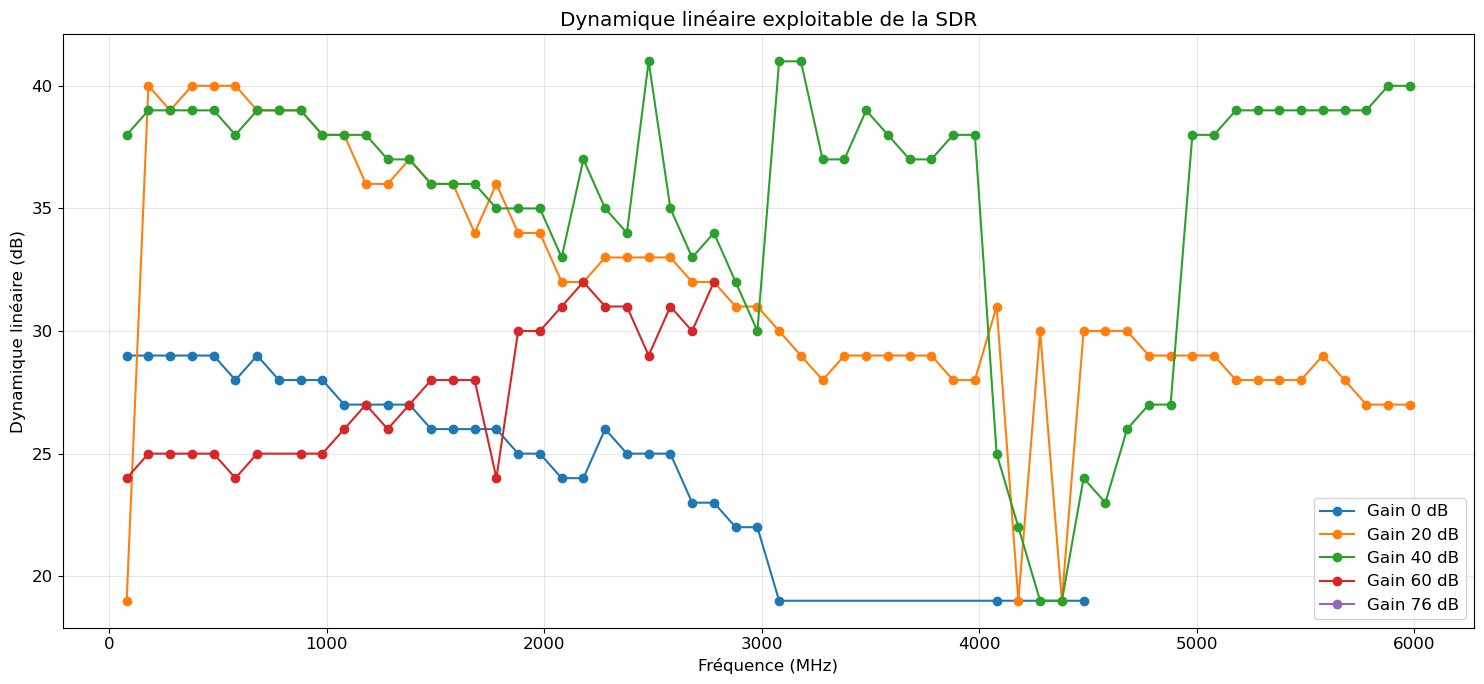

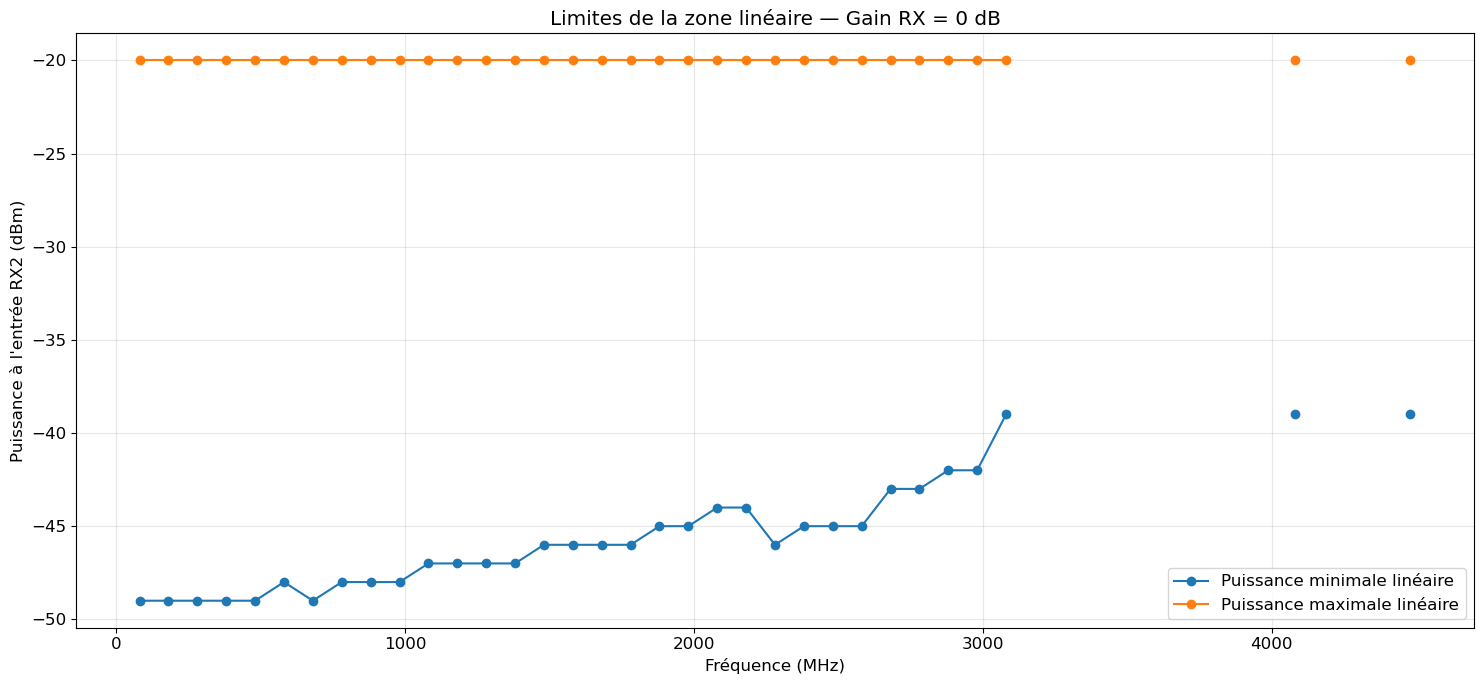

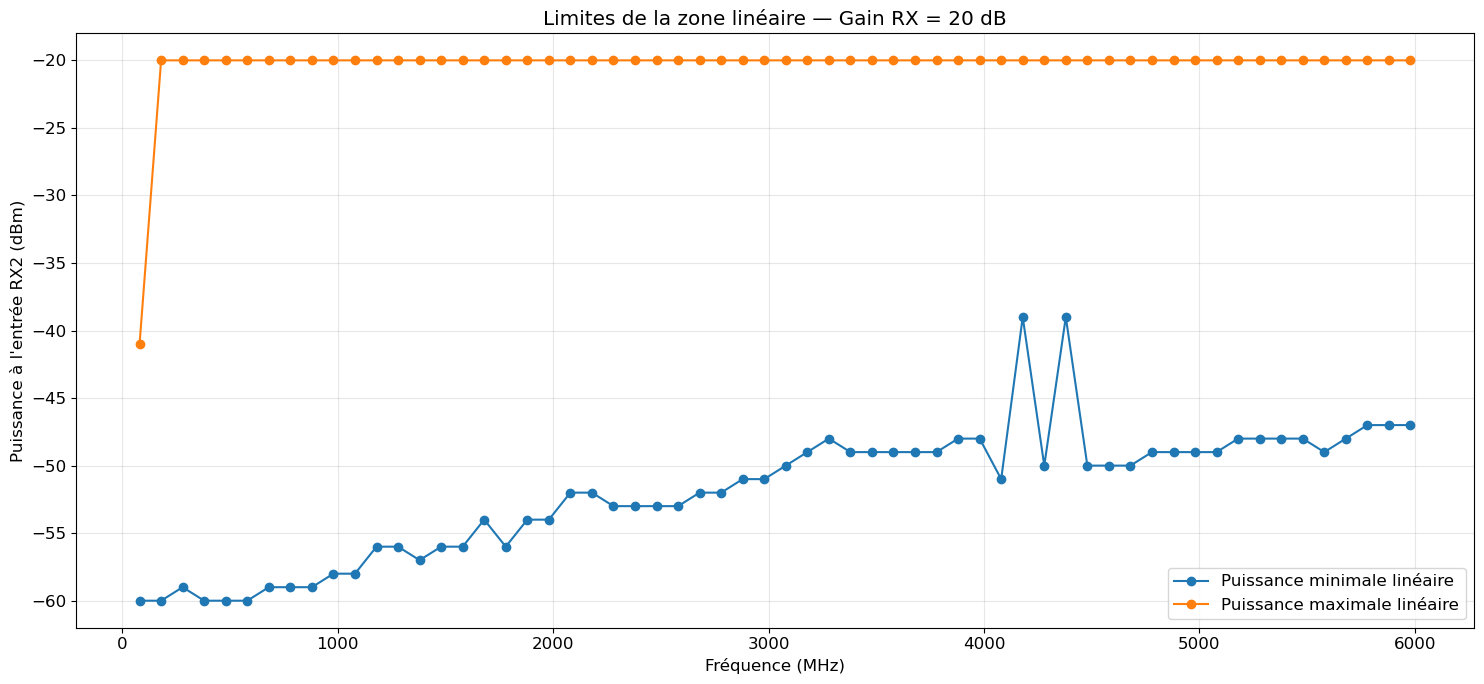

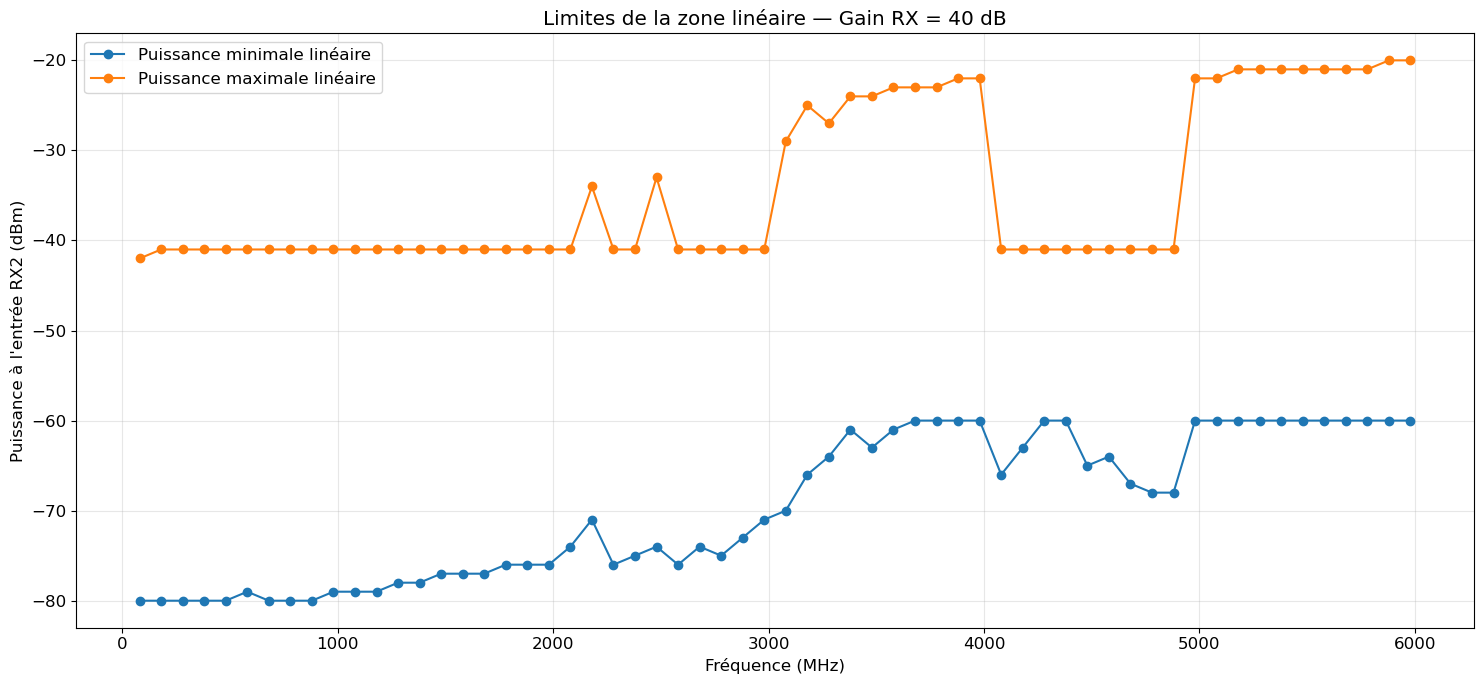

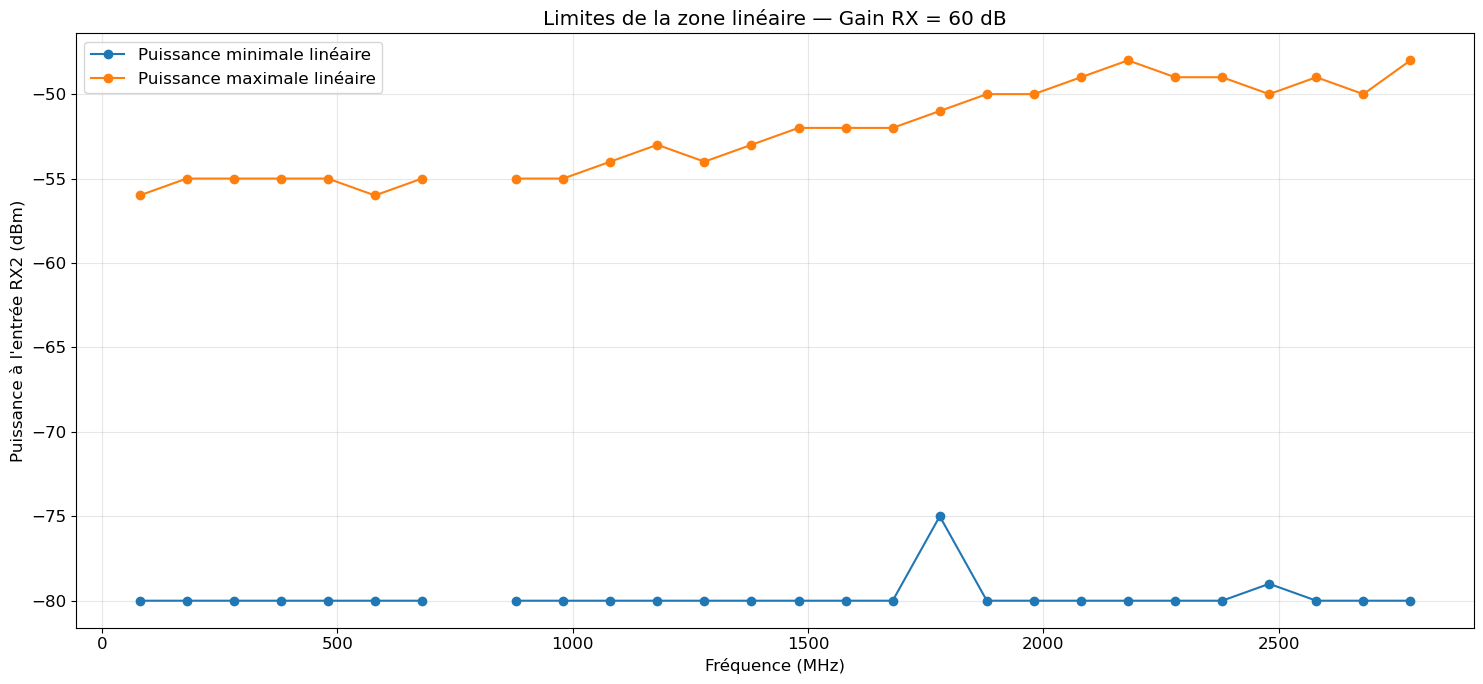

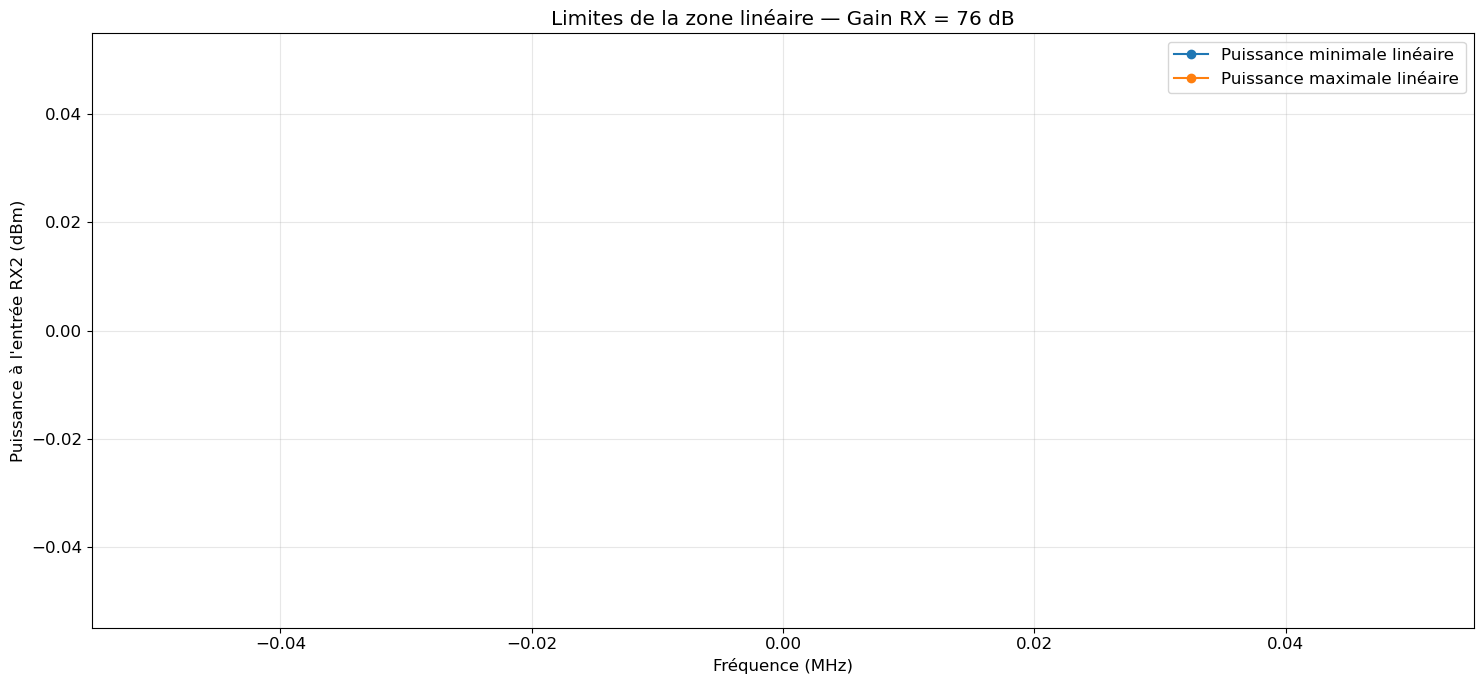

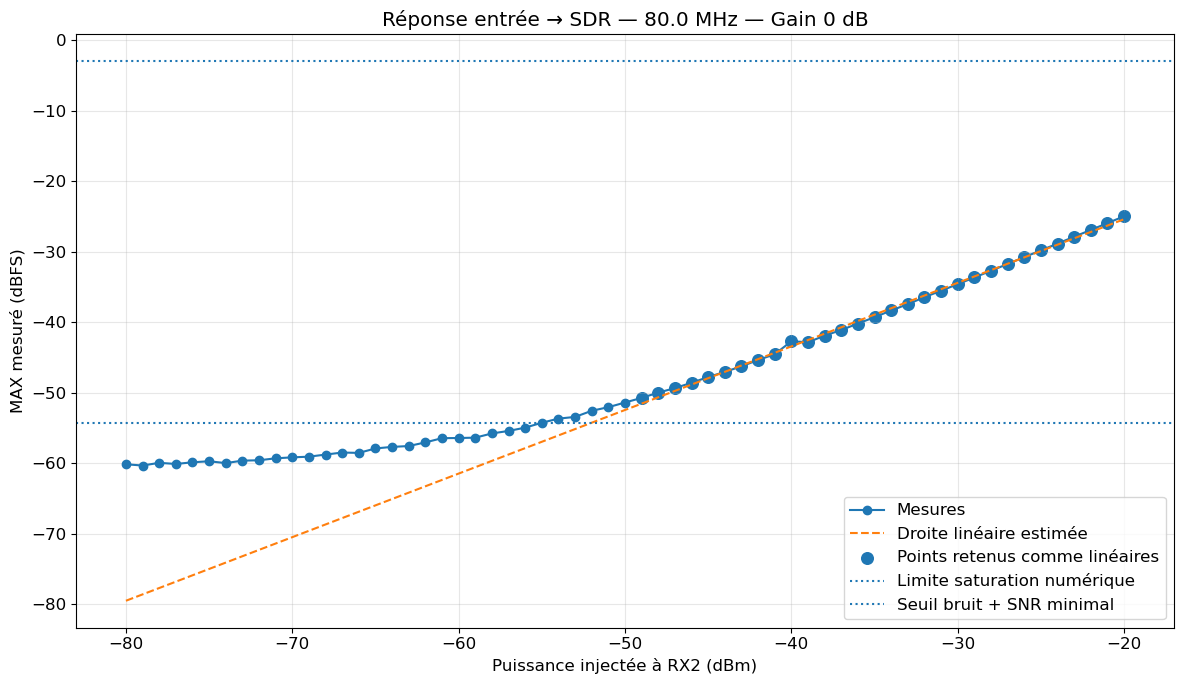

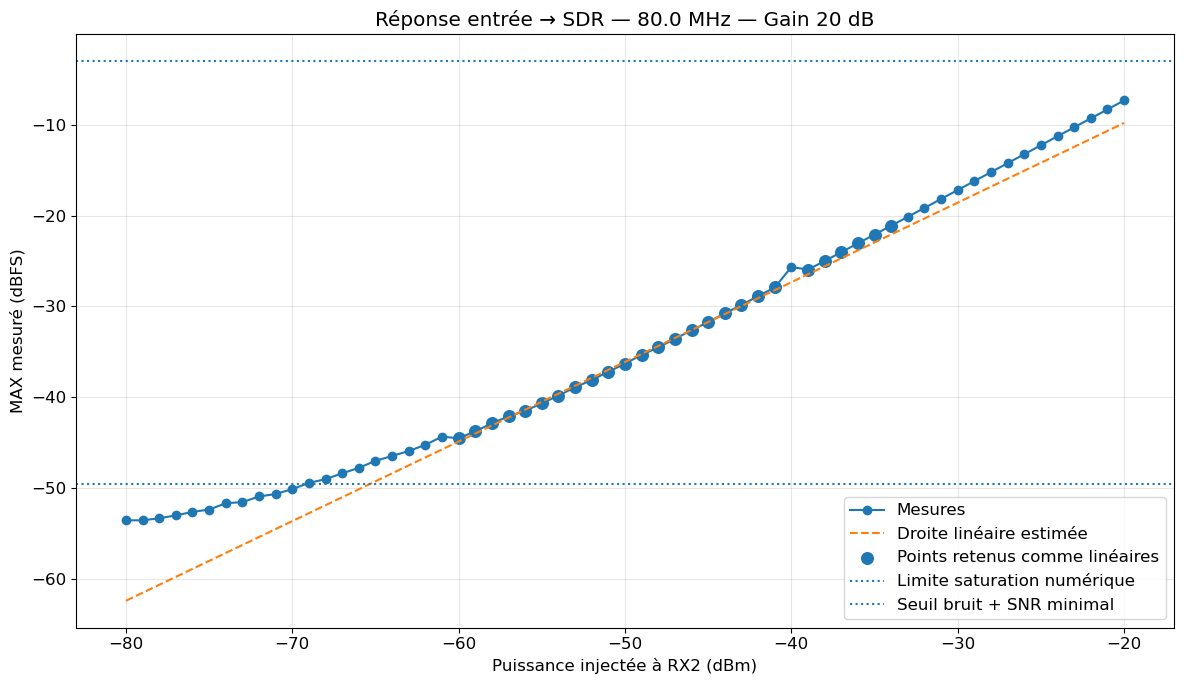

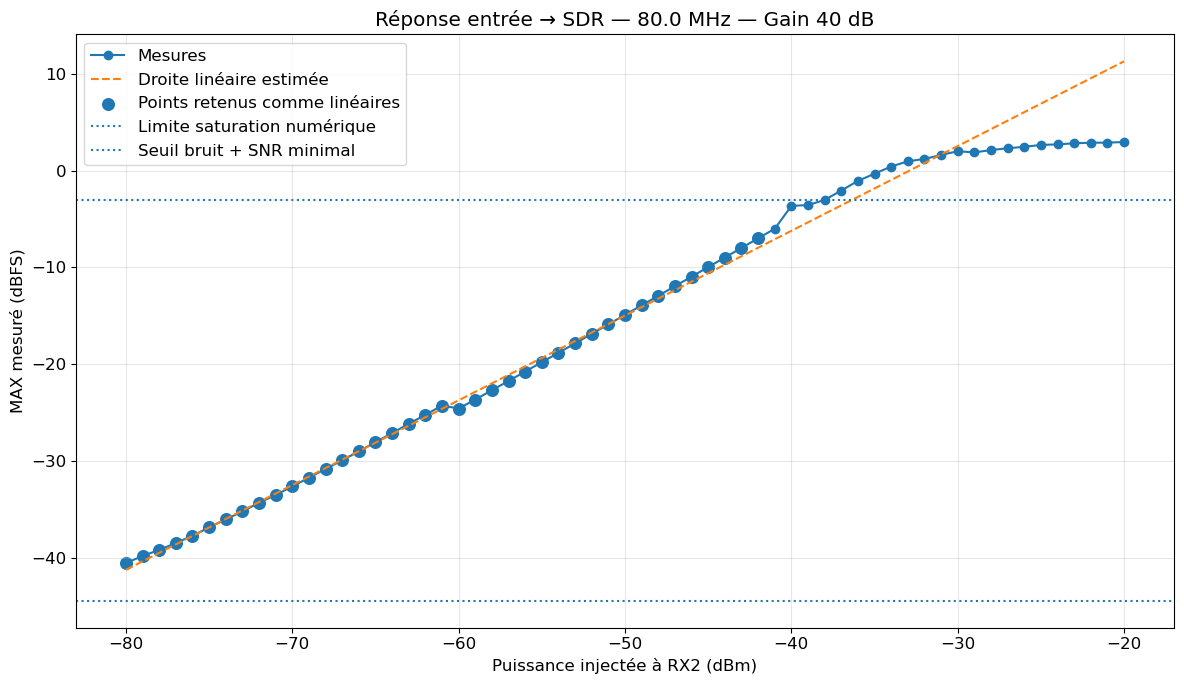

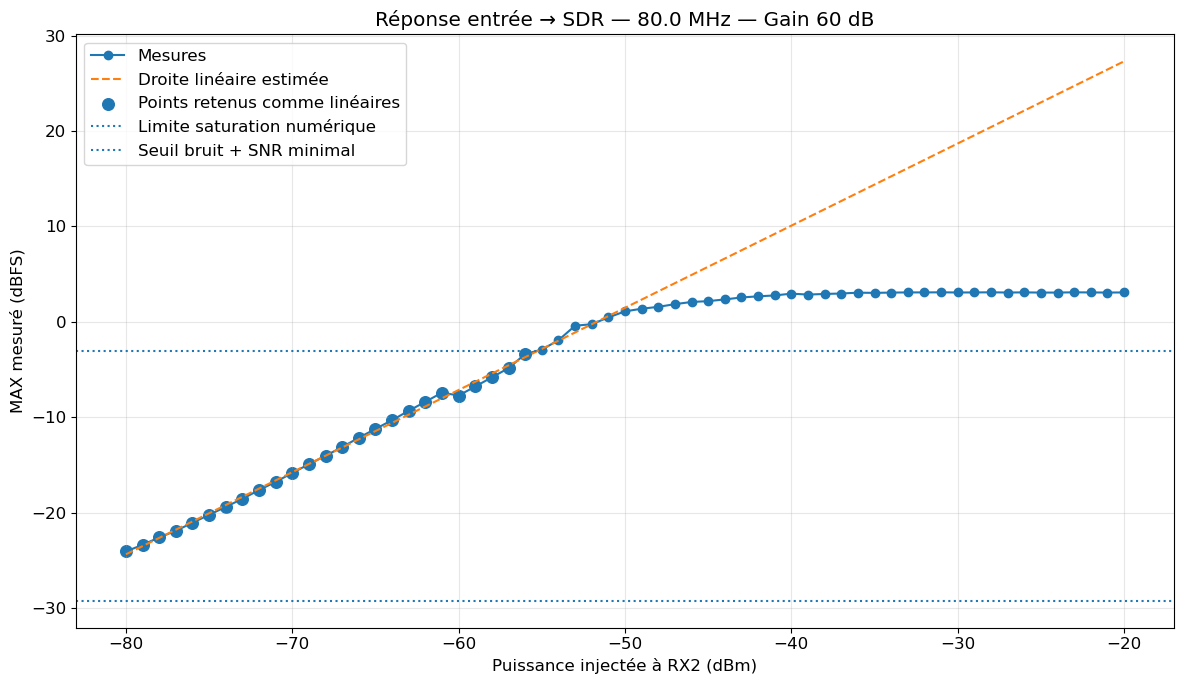

In [10]:
#!/usr/bin/env python3
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# 1) CONFIGURATION
# ============================================================

DATA_DIR = Path("/home/yousef/b200_dynamic_range_max_pulses_BigRange/")

POINTS_CSV = (
    DATA_DIR
    / "dynamic_range_max_aggregated_points.csv"
)

SUMMARY_CSV = (
    DATA_DIR
    / "dynamic_range_max_summary.csv"
)

OUTPUT_CSV = (
    DATA_DIR
    / "dynamic_range_linear_results.csv"
)


# ------------------------------------------------------------
# Sélection des gains
# ------------------------------------------------------------

# None : traiter tous les gains.
# Exemple : 40.0 pour traiter uniquement le gain 40 dB.
SELECTED_GAIN: float | None = None


# ------------------------------------------------------------
# Critères de détection et de linéarité
# ------------------------------------------------------------

# Un point doit être au moins 6 dB au-dessus du bruit.
MIN_SNR_DB = 6.0

# Pour construire la droite initiale, on préfère des points
# clairement au-dessus du bruit.
LINEAR_FIT_MIN_SNR_DB = 12.0

# On exclut de la régression initiale les points trop proches
# de la saturation numérique.
LINEAR_FIT_MAX_DBFS = -12.0

# Écart maximal autorisé par rapport à la droite idéale.
MAX_LINEARITY_ERROR_DB = 1.0

# Niveau maximal autorisé avant de considérer que le signal
# est trop proche de la saturation numérique.
MAX_ALLOWED_DBFS = -3.0

# Nombre minimal de points pour accepter une zone linéaire.
MIN_LINEAR_POINTS = 3

# Pente minimale et maximale acceptable.
# Dans une chaîne linéaire, +1 dB à l'entrée doit donner
# environ +1 dB dans la mesure.
MIN_ACCEPTED_SLOPE = 0.85
MAX_ACCEPTED_SLOPE = 1.15


# ============================================================
# 2) VÉRIFICATION DES COLONNES
# ============================================================

def require_columns(
    dataframe: pd.DataFrame,
    required_columns: list[str],
    dataframe_name: str,
) -> None:
    """
    Vérifie que toutes les colonnes nécessaires existent.
    """

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Colonnes manquantes dans {dataframe_name} : "
            + ", ".join(missing_columns)
        )


# ============================================================
# 3) CHARGEMENT ET NETTOYAGE
# ============================================================

def load_and_prepare_data() -> tuple[
    pd.DataFrame,
    pd.DataFrame,
]:
    """
    Charge les fichiers CSV et prépare les données.
    """

    for csv_file in [
        POINTS_CSV,
        SUMMARY_CSV,
    ]:
        if not csv_file.exists():
            raise FileNotFoundError(
                f"Fichier introuvable : "
                f"{csv_file.resolve()}"
            )

    points_df = pd.read_csv(
        POINTS_CSV
    )

    summary_df = pd.read_csv(
        SUMMARY_CSV
    )

    points_required = [
        "frequency_mhz",
        "gain_db",
        "input_rx2_dbm",
        "max_dbfs",
    ]

    summary_required = [
        "frequency_mhz",
        "gain_db",
        "noise_max_dbfs",
    ]

    require_columns(
        points_df,
        points_required,
        "dynamic_range_max_aggregated_points.csv",
    )

    require_columns(
        summary_df,
        summary_required,
        "dynamic_range_max_summary.csv",
    )

    for column in points_required:
        points_df[column] = pd.to_numeric(
            points_df[column],
            errors="coerce",
        )

    for column in summary_required:
        summary_df[column] = pd.to_numeric(
            summary_df[column],
            errors="coerce",
        )

    points_df = points_df.dropna(
        subset=points_required
    ).copy()

    summary_df = summary_df.dropna(
        subset=summary_required
    ).copy()

    if SELECTED_GAIN is not None:

        points_df = points_df[
            np.isclose(
                points_df["gain_db"],
                SELECTED_GAIN,
                atol=0.1,
            )
        ].copy()

        summary_df = summary_df[
            np.isclose(
                summary_df["gain_db"],
                SELECTED_GAIN,
                atol=0.1,
            )
        ].copy()

    if points_df.empty:
        raise RuntimeError(
            "Aucun point de mesure disponible."
        )

    if summary_df.empty:
        raise RuntimeError(
            "Aucune mesure de bruit disponible."
        )

    return (
        points_df,
        summary_df,
    )


# ============================================================
# 4) RÉCUPÉRATION DU NIVEAU DE BRUIT
# ============================================================

def get_noise_floor_dbfs(
    summary_df: pd.DataFrame,
    frequency_mhz: float,
    gain_db: float,
) -> float:
    """
    Retourne le niveau de bruit pour une fréquence et un gain.
    """

    matching_rows = summary_df[
        np.isclose(
            summary_df["frequency_mhz"],
            frequency_mhz,
            atol=1e-6,
        )
        & np.isclose(
            summary_df["gain_db"],
            gain_db,
            atol=0.1,
        )
    ]

    if matching_rows.empty:
        return np.nan

    return float(
        matching_rows[
            "noise_max_dbfs"
        ].median()
    )


# ============================================================
# 5) PLUS LONGUE ZONE CONTINUE
# ============================================================

def longest_contiguous_true_region(
    dataframe: pd.DataFrame,
    boolean_column: str,
) -> pd.DataFrame:
    """
    Retourne la plus longue suite continue de lignes True.

    Les points doivent préalablement être triés selon
    la puissance injectée.
    """

    dataframe = dataframe.reset_index(
        drop=True
    )

    best_start: int | None = None
    best_end: int | None = None
    current_start: int | None = None

    boolean_values = (
        dataframe[boolean_column]
        .fillna(False)
        .astype(bool)
        .to_numpy()
    )

    for index, is_valid in enumerate(
        boolean_values
    ):

        if is_valid:

            if current_start is None:
                current_start = index

        else:

            if current_start is not None:

                current_end = index - 1

                current_length = (
                    current_end
                    - current_start
                    + 1
                )

                if best_start is None:
                    best_start = current_start
                    best_end = current_end

                else:
                    best_length = (
                        best_end
                        - best_start
                        + 1
                    )

                    if current_length > best_length:
                        best_start = current_start
                        best_end = current_end

                current_start = None

    # La dernière zone peut aller jusqu'au dernier point.
    if current_start is not None:

        current_end = len(dataframe) - 1

        current_length = (
            current_end
            - current_start
            + 1
        )

        if best_start is None:
            best_start = current_start
            best_end = current_end

        else:
            best_length = (
                best_end
                - best_start
                + 1
            )

            if current_length > best_length:
                best_start = current_start
                best_end = current_end

    if (
        best_start is None
        or best_end is None
    ):
        return dataframe.iloc[
            0:0
        ].copy()

    return dataframe.iloc[
        best_start:
        best_end + 1
    ].copy()


# ============================================================
# 6) RÉGRESSION LINÉAIRE
# ============================================================

def linear_regression(
    dataframe: pd.DataFrame,
) -> dict:
    """
    Effectue la régression :

        max_dbfs =
            slope * input_rx2_dbm
            + intercept
    """

    x = dataframe[
        "input_rx2_dbm"
    ].to_numpy(dtype=float)

    y = dataframe[
        "max_dbfs"
    ].to_numpy(dtype=float)

    if len(x) < MIN_LINEAR_POINTS:
        return {
            "slope": np.nan,
            "intercept": np.nan,
            "rmse_db": np.nan,
            "r_squared": np.nan,
        }

    if np.ptp(x) <= 0:
        return {
            "slope": np.nan,
            "intercept": np.nan,
            "rmse_db": np.nan,
            "r_squared": np.nan,
        }

    slope, intercept = np.polyfit(
        x,
        y,
        1,
    )

    predicted = (
        slope * x
        + intercept
    )

    residuals = (
        y
        - predicted
    )

    rmse_db = float(
        np.sqrt(
            np.mean(
                residuals**2
            )
        )
    )

    ss_res = float(
        np.sum(
            residuals**2
        )
    )

    ss_tot = float(
        np.sum(
            (
                y
                - np.mean(y)
            ) ** 2
        )
    )

    if ss_tot > 0:
        r_squared = float(
            1.0
            - ss_res / ss_tot
        )
    else:
        r_squared = np.nan

    return {
        "slope": float(slope),
        "intercept": float(intercept),
        "rmse_db": rmse_db,
        "r_squared": r_squared,
    }


# ============================================================
# 7) CALCUL POUR UNE FRÉQUENCE ET UN GAIN
# ============================================================

def calculate_case_dynamic_range(
    case_df: pd.DataFrame,
    noise_dbfs: float,
    frequency_mhz: float,
    gain_db: float,
) -> tuple[dict, pd.DataFrame]:
    """
    Calcule la zone linéaire pour une fréquence et un gain.
    """

    # Si plusieurs lignes existent pour la même puissance injectée,
    # on prend la médiane des résultats.
    case_df = (
        case_df.groupby(
            "input_rx2_dbm",
            as_index=False,
        )
        .agg(
            max_dbfs=(
                "max_dbfs",
                "median",
            ),
            number_of_points=(
                "max_dbfs",
                "size",
            ),
        )
        .sort_values(
            "input_rx2_dbm"
        )
        .reset_index(
            drop=True
        )
    )

    case_df["snr_db"] = (
        case_df["max_dbfs"]
        - noise_dbfs
    )

    # --------------------------------------------------------
    # Points candidats pour construire la première droite
    # --------------------------------------------------------

    initial_fit_candidates = case_df[
        (
            case_df["snr_db"]
            >= LINEAR_FIT_MIN_SNR_DB
        )
        & (
            case_df["max_dbfs"]
            <= LINEAR_FIT_MAX_DBFS
        )
    ].copy()

    initial_fit = linear_regression(
        initial_fit_candidates
    )

    initial_slope = initial_fit[
        "slope"
    ]

    initial_intercept = initial_fit[
        "intercept"
    ]

    # Colonnes par défaut.
    case_df["predicted_dbfs"] = np.nan
    case_df["linearity_error_db"] = np.nan
    case_df["compression_db"] = np.nan
    case_df["is_above_noise"] = False
    case_df["is_below_saturation"] = False
    case_df["is_close_to_line"] = False
    case_df["is_linear_initial"] = False
    case_df["is_linear_final"] = False

    minimum_linear_dbm = np.nan
    maximum_linear_dbm = np.nan

    minimum_linear_dbfs = np.nan
    maximum_linear_dbfs = np.nan

    dynamic_range_db = np.nan

    final_slope = np.nan
    final_intercept = np.nan
    final_rmse_db = np.nan
    final_r_squared = np.nan

    first_non_detectable_dbm = np.nan
    first_compressed_dbm = np.nan
    first_saturated_dbm = np.nan

    number_of_linear_points = 0

    slope_is_valid = bool(
        np.isfinite(initial_slope)
        and MIN_ACCEPTED_SLOPE
        <= initial_slope
        <= MAX_ACCEPTED_SLOPE
    )

    if slope_is_valid:

        case_df["predicted_dbfs"] = (
            initial_slope
            * case_df["input_rx2_dbm"]
            + initial_intercept
        )

        # Erreur absolue par rapport à la réponse linéaire.
        case_df["linearity_error_db"] = np.abs(
            case_df["max_dbfs"]
            - case_df["predicted_dbfs"]
        )

        # Compression positive lorsque la mesure réelle est
        # plus faible que la valeur prévue.
        case_df["compression_db"] = (
            case_df["predicted_dbfs"]
            - case_df["max_dbfs"]
        )

        case_df["is_above_noise"] = (
            case_df["snr_db"]
            >= MIN_SNR_DB
        )

        case_df["is_below_saturation"] = (
            case_df["max_dbfs"]
            <= MAX_ALLOWED_DBFS
        )

        case_df["is_close_to_line"] = (
            case_df["linearity_error_db"]
            <= MAX_LINEARITY_ERROR_DB
        )

        case_df["is_linear_initial"] = (
            case_df["is_above_noise"]
            & case_df["is_below_saturation"]
            & case_df["is_close_to_line"]
        )

        # ----------------------------------------------------
        # Plus longue première zone linéaire
        # ----------------------------------------------------

        initial_linear_region = (
            longest_contiguous_true_region(
                case_df,
                "is_linear_initial",
            )
        )

        if (
            len(initial_linear_region)
            >= MIN_LINEAR_POINTS
        ):

            # Deuxième régression uniquement sur la zone
            # considérée linéaire.
            final_fit = linear_regression(
                initial_linear_region
            )

            final_slope = final_fit[
                "slope"
            ]

            final_intercept = final_fit[
                "intercept"
            ]

            final_rmse_db = final_fit[
                "rmse_db"
            ]

            final_r_squared = final_fit[
                "r_squared"
            ]

            final_slope_is_valid = bool(
                np.isfinite(final_slope)
                and MIN_ACCEPTED_SLOPE
                <= final_slope
                <= MAX_ACCEPTED_SLOPE
            )

            if final_slope_is_valid:

                # Recalcul final des erreurs avec la droite
                # construite sur la zone linéaire.
                case_df["predicted_dbfs"] = (
                    final_slope
                    * case_df["input_rx2_dbm"]
                    + final_intercept
                )

                case_df["linearity_error_db"] = np.abs(
                    case_df["max_dbfs"]
                    - case_df["predicted_dbfs"]
                )

                case_df["compression_db"] = (
                    case_df["predicted_dbfs"]
                    - case_df["max_dbfs"]
                )

                case_df["is_close_to_line"] = (
                    case_df["linearity_error_db"]
                    <= MAX_LINEARITY_ERROR_DB
                )

                case_df["is_linear_final"] = (
                    case_df["is_above_noise"]
                    & case_df["is_below_saturation"]
                    & case_df["is_close_to_line"]
                )

                # Plus longue zone continue finale.
                final_linear_region = (
                    longest_contiguous_true_region(
                        case_df,
                        "is_linear_final",
                    )
                )

                if (
                    len(final_linear_region)
                    >= MIN_LINEAR_POINTS
                ):

                    minimum_row = (
                        final_linear_region.iloc[0]
                    )

                    maximum_row = (
                        final_linear_region.iloc[-1]
                    )

                    minimum_linear_dbm = float(
                        minimum_row[
                            "input_rx2_dbm"
                        ]
                    )

                    maximum_linear_dbm = float(
                        maximum_row[
                            "input_rx2_dbm"
                        ]
                    )

                    minimum_linear_dbfs = float(
                        minimum_row[
                            "max_dbfs"
                        ]
                    )

                    maximum_linear_dbfs = float(
                        maximum_row[
                            "max_dbfs"
                        ]
                    )

                    dynamic_range_db = float(
                        maximum_linear_dbm
                        - minimum_linear_dbm
                    )

                    number_of_linear_points = int(
                        len(final_linear_region)
                    )

    # --------------------------------------------------------
    # Diagnostic des points rejetés
    # --------------------------------------------------------

    below_noise_df = case_df[
        case_df["snr_db"]
        < MIN_SNR_DB
    ]

    if not below_noise_df.empty:
        first_non_detectable_dbm = float(
            below_noise_df.iloc[-1][
                "input_rx2_dbm"
            ]
        )

    compressed_df = case_df[
        case_df["compression_db"]
        > MAX_LINEARITY_ERROR_DB
    ]

    if not compressed_df.empty:
        first_compressed_dbm = float(
            compressed_df.iloc[0][
                "input_rx2_dbm"
            ]
        )

    saturated_df = case_df[
        case_df["max_dbfs"]
        > MAX_ALLOWED_DBFS
    ]

    if not saturated_df.empty:
        first_saturated_dbm = float(
            saturated_df.iloc[0][
                "input_rx2_dbm"
            ]
        )

    result = {
        "frequency_mhz": float(
            frequency_mhz
        ),

        "gain_db": float(
            gain_db
        ),

        "noise_max_dbfs": float(
            noise_dbfs
        ),

        "minimum_linear_dbm": (
            minimum_linear_dbm
        ),

        "maximum_linear_dbm": (
            maximum_linear_dbm
        ),

        "minimum_linear_dbfs": (
            minimum_linear_dbfs
        ),

        "maximum_linear_dbfs": (
            maximum_linear_dbfs
        ),

        "dynamic_range_db": (
            dynamic_range_db
        ),

        "linear_fit_slope": (
            final_slope
        ),

        "linear_fit_intercept": (
            final_intercept
        ),

        "linear_fit_rmse_db": (
            final_rmse_db
        ),

        "linear_fit_r_squared": (
            final_r_squared
        ),

        "number_of_input_levels": int(
            len(case_df)
        ),

        "number_of_linear_points": (
            number_of_linear_points
        ),

        "last_point_below_detection_dbm": (
            first_non_detectable_dbm
        ),

        "first_compressed_dbm": (
            first_compressed_dbm
        ),

        "first_saturated_dbm": (
            first_saturated_dbm
        ),
    }

    case_df["frequency_mhz"] = float(
        frequency_mhz
    )

    case_df["gain_db"] = float(
        gain_db
    )

    case_df["noise_max_dbfs"] = float(
        noise_dbfs
    )

    return (
        result,
        case_df,
    )


# ============================================================
# 8) CALCUL POUR TOUTES LES FRÉQUENCES ET TOUS LES GAINS
# ============================================================

def calculate_all_dynamic_ranges(
    points_df: pd.DataFrame,
    summary_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    results = []
    detailed_results = []

    grouped = points_df.groupby(
        [
            "gain_db",
            "frequency_mhz",
        ]
    )

    for (
        gain_db,
        frequency_mhz,
    ), case_df in grouped:

        noise_dbfs = get_noise_floor_dbfs(
            summary_df=summary_df,
            frequency_mhz=float(
                frequency_mhz
            ),
            gain_db=float(
                gain_db
            ),
        )

        if not np.isfinite(noise_dbfs):

            print(
                f"Attention : aucun bruit trouvé pour "
                f"{frequency_mhz:.1f} MHz, "
                f"gain {gain_db:.1f} dB."
            )

            continue

        result, detailed_case_df = (
            calculate_case_dynamic_range(
                case_df=case_df,
                noise_dbfs=noise_dbfs,
                frequency_mhz=float(
                    frequency_mhz
                ),
                gain_db=float(
                    gain_db
                ),
            )
        )

        results.append(
            result
        )

        detailed_results.append(
            detailed_case_df
        )

    results_df = pd.DataFrame(
        results
    )

    if results_df.empty:
        raise RuntimeError(
            "Aucune dynamique n'a pu être calculée."
        )

    results_df = results_df.sort_values(
        [
            "gain_db",
            "frequency_mhz",
        ]
    ).reset_index(
        drop=True
    )

    if detailed_results:
        detailed_df = pd.concat(
            detailed_results,
            ignore_index=True,
        )
    else:
        detailed_df = pd.DataFrame()

    return (
        results_df,
        detailed_df,
    )


# ============================================================
# 9) AFFICHAGE TEXTE
# ============================================================

def print_results(
    results_df: pd.DataFrame,
) -> None:

    print()
    print("=" * 125)
    print(
        "DYNAMIQUE LINÉAIRE DE LA SDR"
    )
    print("=" * 125)

    display_columns = [
        "frequency_mhz",
        "gain_db",
        "noise_max_dbfs",
        "minimum_linear_dbm",
        "maximum_linear_dbm",
        "dynamic_range_db",
        "linear_fit_slope",
        "linear_fit_r_squared",
        "number_of_linear_points",
    ]

    print(
        results_df[
            display_columns
        ].to_string(
            index=False,
            float_format=(
                lambda value:
                f"{value:.2f}"
            ),
        )
    )

    print()
    print(
        "Définition utilisée :"
    )

    print(
        "Dynamique linéaire = "
        "puissance maximale linéaire "
        "- puissance minimale linéaire"
    )

    print(
        f"SNR minimal : "
        f"{MIN_SNR_DB:.1f} dB"
    )

    print(
        f"Erreur de linéarité maximale : "
        f"{MAX_LINEARITY_ERROR_DB:.1f} dB"
    )

    print(
        f"Niveau maximal numérique : "
        f"{MAX_ALLOWED_DBFS:.1f} dBFS"
    )

    print(
        f"Pente acceptée : "
        f"{MIN_ACCEPTED_SLOPE:.2f} à "
        f"{MAX_ACCEPTED_SLOPE:.2f}"
    )


# ============================================================
# 10) GRAPHES
# ============================================================

def plot_dynamic_range(
    results_df: pd.DataFrame,
) -> None:

    plt.figure(
        figsize=(15, 7)
    )

    for gain_db in sorted(
        results_df[
            "gain_db"
        ].dropna().unique()
    ):

        gain_df = results_df[
            np.isclose(
                results_df["gain_db"],
                gain_db,
                atol=0.1,
            )
        ].dropna(
            subset=[
                "dynamic_range_db"
            ]
        )

        plt.plot(
            gain_df["frequency_mhz"],
            gain_df["dynamic_range_db"],
            marker="o",
            linewidth=1.5,
            label=f"Gain {gain_db:.0f} dB",
        )

    plt.title(
        "Dynamique linéaire exploitable de la SDR"
    )

    plt.xlabel(
        "Fréquence (MHz)"
    )

    plt.ylabel(
        "Dynamique linéaire (dB)"
    )

    plt.grid(
        True,
        alpha=0.3,
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_linear_limits(
    results_df: pd.DataFrame,
) -> None:

    for gain_db in sorted(
        results_df[
            "gain_db"
        ].dropna().unique()
    ):

        gain_df = results_df[
            np.isclose(
                results_df["gain_db"],
                gain_db,
                atol=0.1,
            )
        ].sort_values(
            "frequency_mhz"
        )

        plt.figure(
            figsize=(15, 7)
        )

        plt.plot(
            gain_df["frequency_mhz"],
            gain_df["minimum_linear_dbm"],
            marker="o",
            linewidth=1.5,
            label="Puissance minimale linéaire",
        )

        plt.plot(
            gain_df["frequency_mhz"],
            gain_df["maximum_linear_dbm"],
            marker="o",
            linewidth=1.5,
            label="Puissance maximale linéaire",
        )

        plt.title(
            "Limites de la zone linéaire — "
            f"Gain RX = {gain_db:.0f} dB"
        )

        plt.xlabel(
            "Fréquence (MHz)"
        )

        plt.ylabel(
            "Puissance à l'entrée RX2 (dBm)"
        )

        plt.grid(
            True,
            alpha=0.3,
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_example_response(
    detailed_df: pd.DataFrame,
    results_df: pd.DataFrame,
) -> None:
    """
    Affiche un exemple de courbe entrée -> dBFS pour la
    première fréquence valide de chaque gain.
    """

    for gain_db in sorted(
        results_df[
            "gain_db"
        ].dropna().unique()
    ):

        valid_results = results_df[
            np.isclose(
                results_df["gain_db"],
                gain_db,
                atol=0.1,
            )
            & results_df[
                "dynamic_range_db"
            ].notna()
        ]

        if valid_results.empty:
            continue

        result_row = valid_results.iloc[0]

        frequency_mhz = float(
            result_row[
                "frequency_mhz"
            ]
        )

        case_df = detailed_df[
            np.isclose(
                detailed_df["gain_db"],
                gain_db,
                atol=0.1,
            )
            & np.isclose(
                detailed_df["frequency_mhz"],
                frequency_mhz,
                atol=1e-6,
            )
        ].sort_values(
            "input_rx2_dbm"
        )

        plt.figure(
            figsize=(12, 7)
        )

        plt.plot(
            case_df["input_rx2_dbm"],
            case_df["max_dbfs"],
            marker="o",
            linewidth=1.5,
            label="Mesures",
        )

        valid_prediction = case_df[
            "predicted_dbfs"
        ].notna()

        if valid_prediction.any():

            plt.plot(
                case_df.loc[
                    valid_prediction,
                    "input_rx2_dbm",
                ],
                case_df.loc[
                    valid_prediction,
                    "predicted_dbfs",
                ],
                linestyle="--",
                linewidth=1.5,
                label="Droite linéaire estimée",
            )

        linear_points = case_df[
            case_df[
                "is_linear_final"
            ]
        ]

        if not linear_points.empty:

            plt.scatter(
                linear_points[
                    "input_rx2_dbm"
                ],
                linear_points[
                    "max_dbfs"
                ],
                s=70,
                label="Points retenus comme linéaires",
            )

        plt.axhline(
            MAX_ALLOWED_DBFS,
            linestyle=":",
            linewidth=1.5,
            label="Limite saturation numérique",
        )

        plt.axhline(
            float(
                case_df[
                    "noise_max_dbfs"
                ].iloc[0]
            )
            + MIN_SNR_DB,
            linestyle=":",
            linewidth=1.5,
            label="Seuil bruit + SNR minimal",
        )

        plt.title(
            f"Réponse entrée → SDR — "
            f"{frequency_mhz:.1f} MHz — "
            f"Gain {gain_db:.0f} dB"
        )

        plt.xlabel(
            "Puissance injectée à RX2 (dBm)"
        )

        plt.ylabel(
            "MAX mesuré (dBFS)"
        )

        plt.grid(
            True,
            alpha=0.3,
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


# ============================================================
# 11) MAIN
# ============================================================

def main() -> None:

    print(
        "Chargement des mesures..."
    )

    points_df, summary_df = (
        load_and_prepare_data()
    )

    print(
        f"Nombre de points : "
        f"{len(points_df)}"
    )

    print(
        "Gains disponibles : "
        f"{sorted(points_df['gain_db'].unique())}"
    )

    results_df, detailed_df = (
        calculate_all_dynamic_ranges(
            points_df=points_df,
            summary_df=summary_df,
        )
    )

    results_df.to_csv(
        OUTPUT_CSV,
        index=False,
    )

    detailed_output_csv = (
        DATA_DIR
        / "dynamic_range_linear_detailed_points.csv"
    )

    detailed_df.to_csv(
        detailed_output_csv,
        index=False,
    )

    print_results(
        results_df
    )

    print()
    print(
        "Résumé enregistré dans : "
        f"{OUTPUT_CSV.resolve()}"
    )

    print(
        "Détails enregistrés dans : "
        f"{detailed_output_csv.resolve()}"
    )

    plot_dynamic_range(
        results_df
    )

    plot_linear_limits(
        results_df
    )

    plot_example_response(
        detailed_df,
        results_df,
    )


if __name__ == "__main__":
    main()

Chargement des mesures...
Nombre de points de mesure : 18300
Gains trouvés dans les mesures : [0.0, 20.0, 40.0, 60.0, 76.0]

Chargement de la calibration RX2...
Plage de calibration : 100.0 MHz à 2000.0 MHz
Gains calibrés : [0.0, 20.0, 40.0, 60.0, 76.0]
Calibration indisponible pour 80.0 MHz, gain 0.0 dB : Fréquence 80.0 MHz inférieure à la fréquence calibrée minimale 100.0 MHz.
Calibration indisponible pour 2080.0 MHz, gain 0.0 dB : Fréquence 2080.0 MHz supérieure à la fréquence calibrée maximale 2000.0 MHz.
Calibration indisponible pour 2180.0 MHz, gain 0.0 dB : Fréquence 2180.0 MHz supérieure à la fréquence calibrée maximale 2000.0 MHz.
Calibration indisponible pour 2280.0 MHz, gain 0.0 dB : Fréquence 2280.0 MHz supérieure à la fréquence calibrée maximale 2000.0 MHz.
Calibration indisponible pour 2380.0 MHz, gain 0.0 dB : Fréquence 2380.0 MHz supérieure à la fréquence calibrée maximale 2000.0 MHz.
Calibration indisponible pour 2480.0 MHz, gain 0.0 dB : Fréquence 2480.0 MHz supérieur

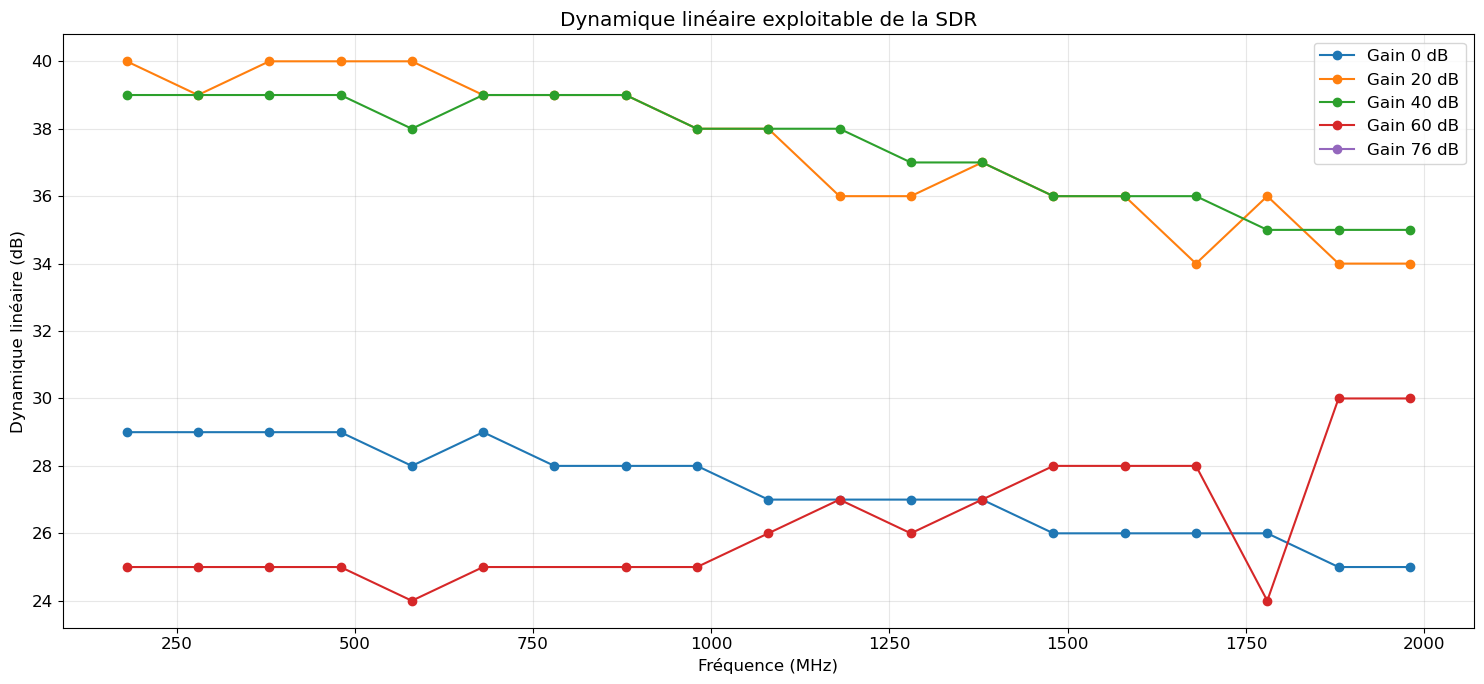

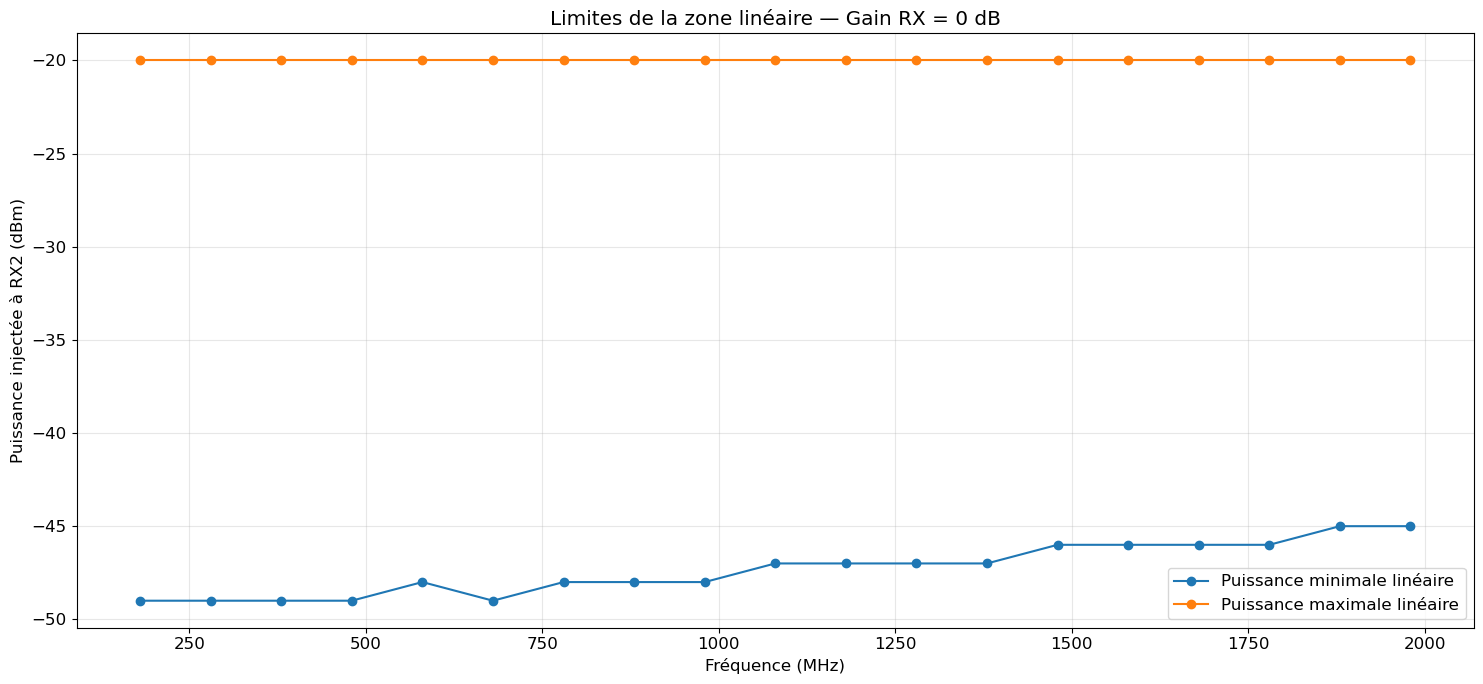

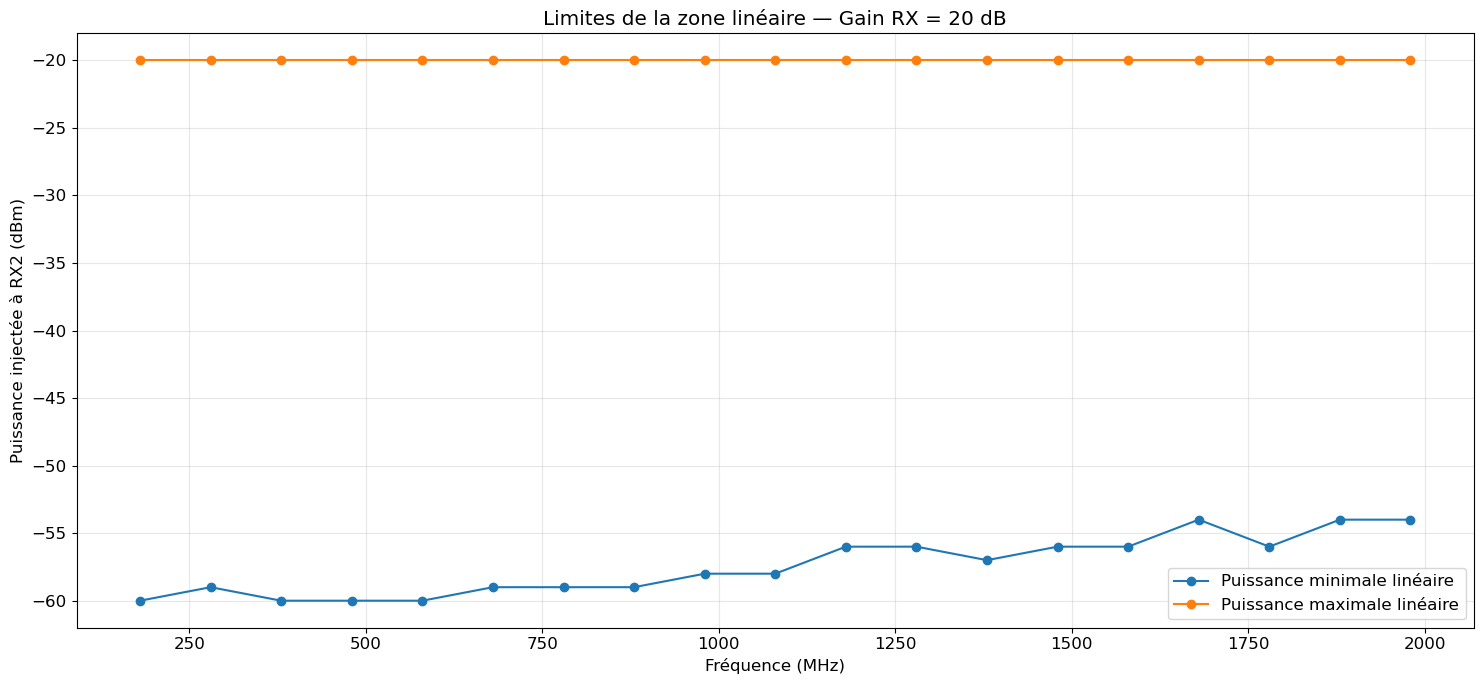

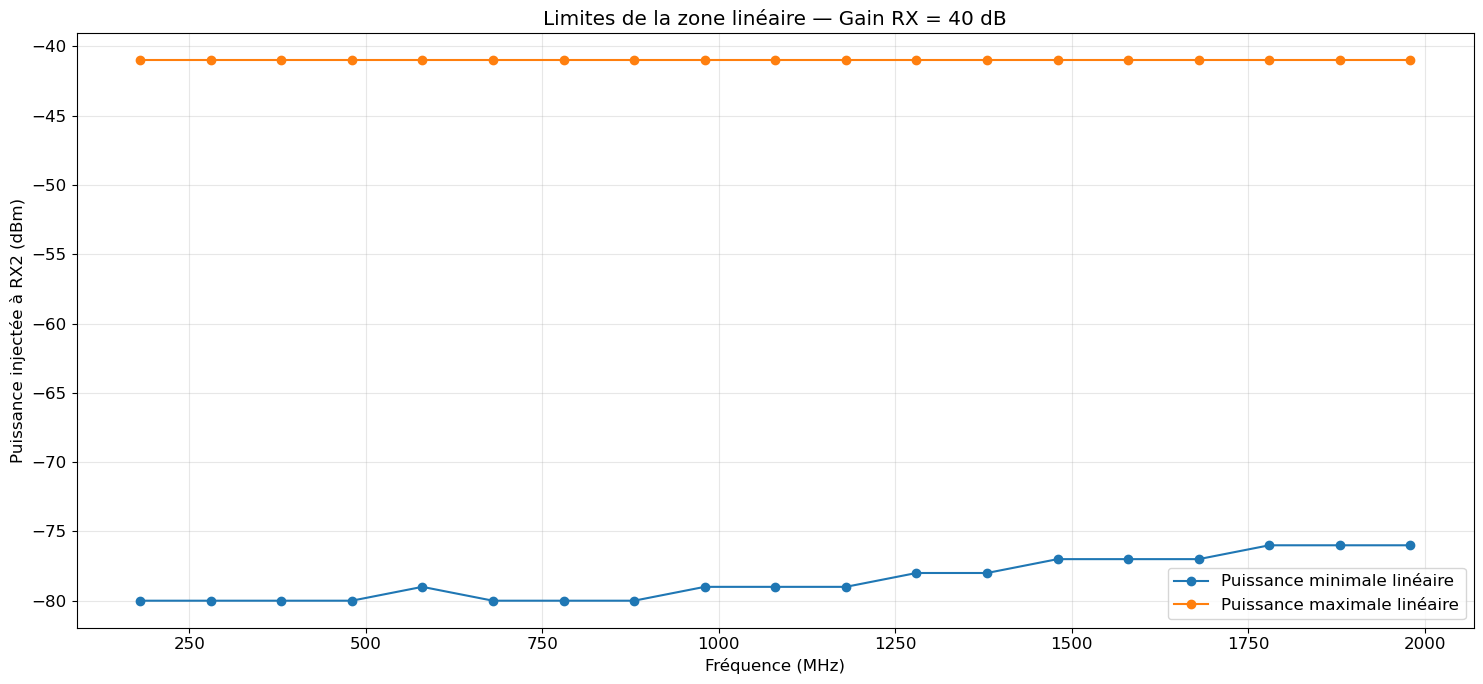

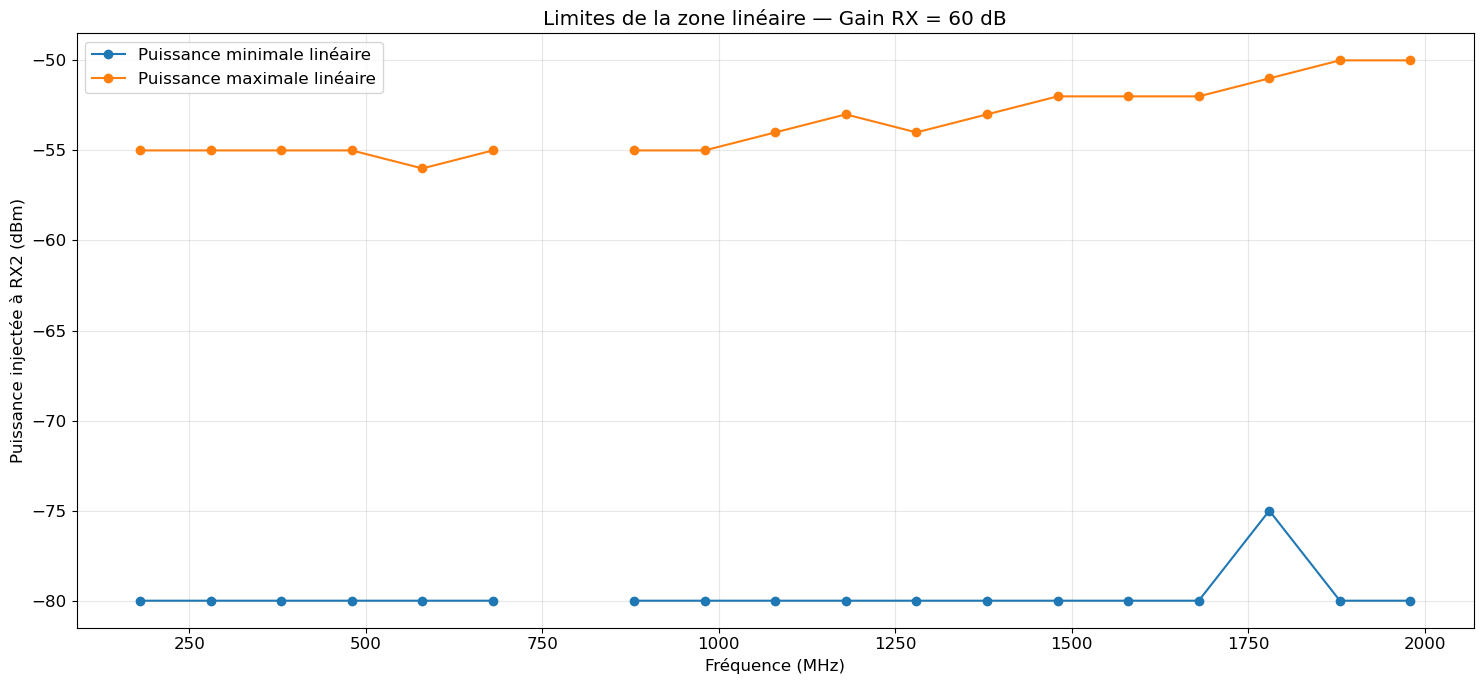

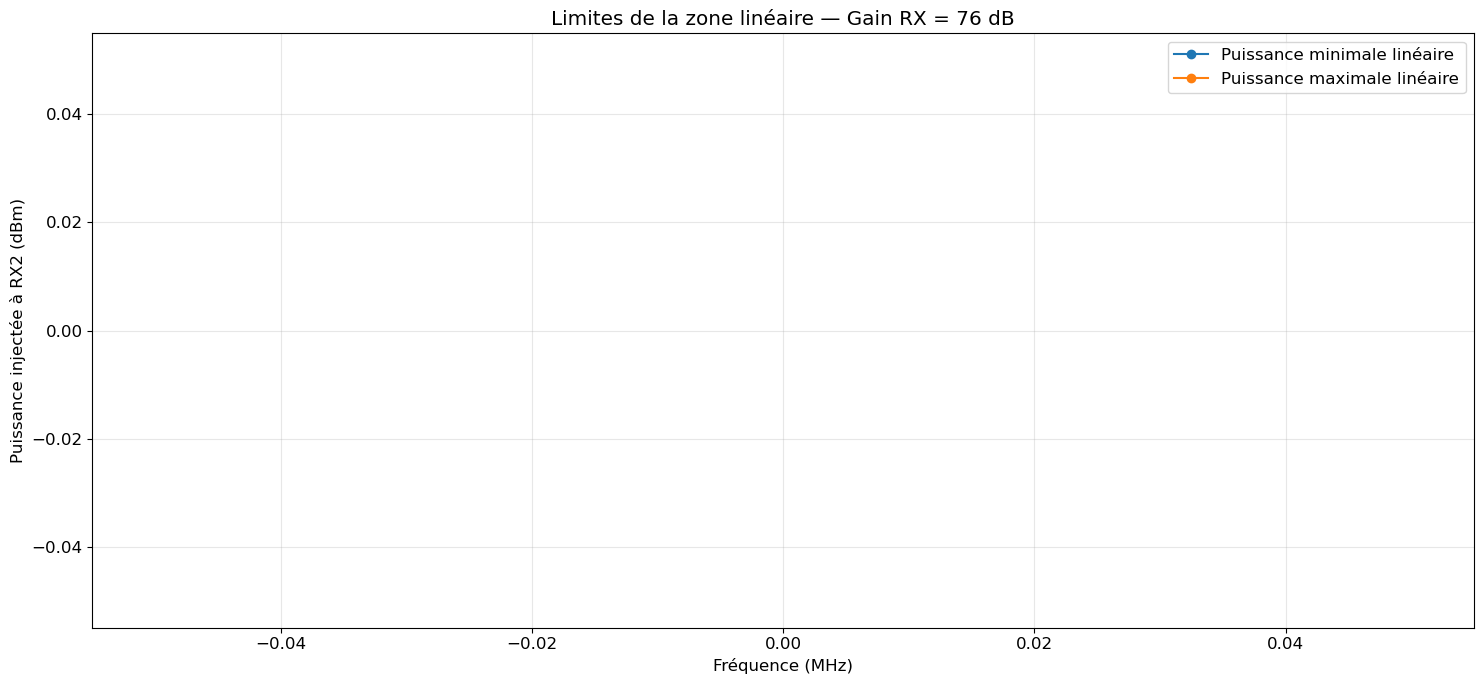

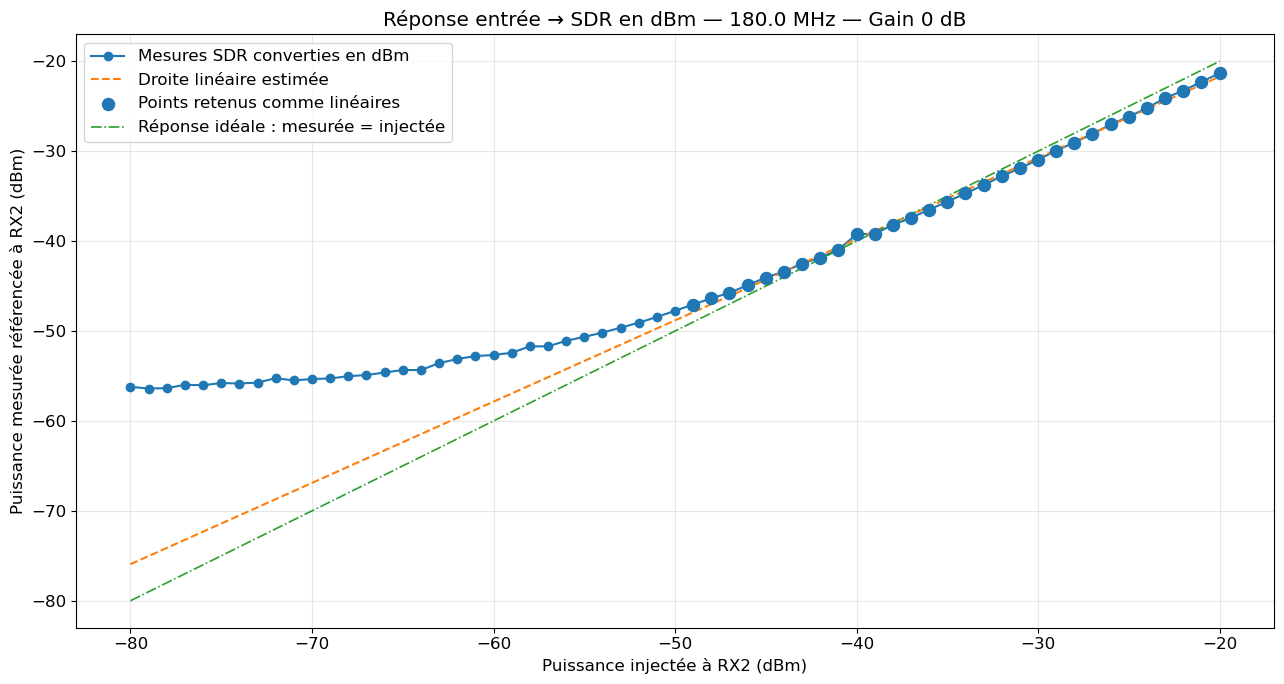

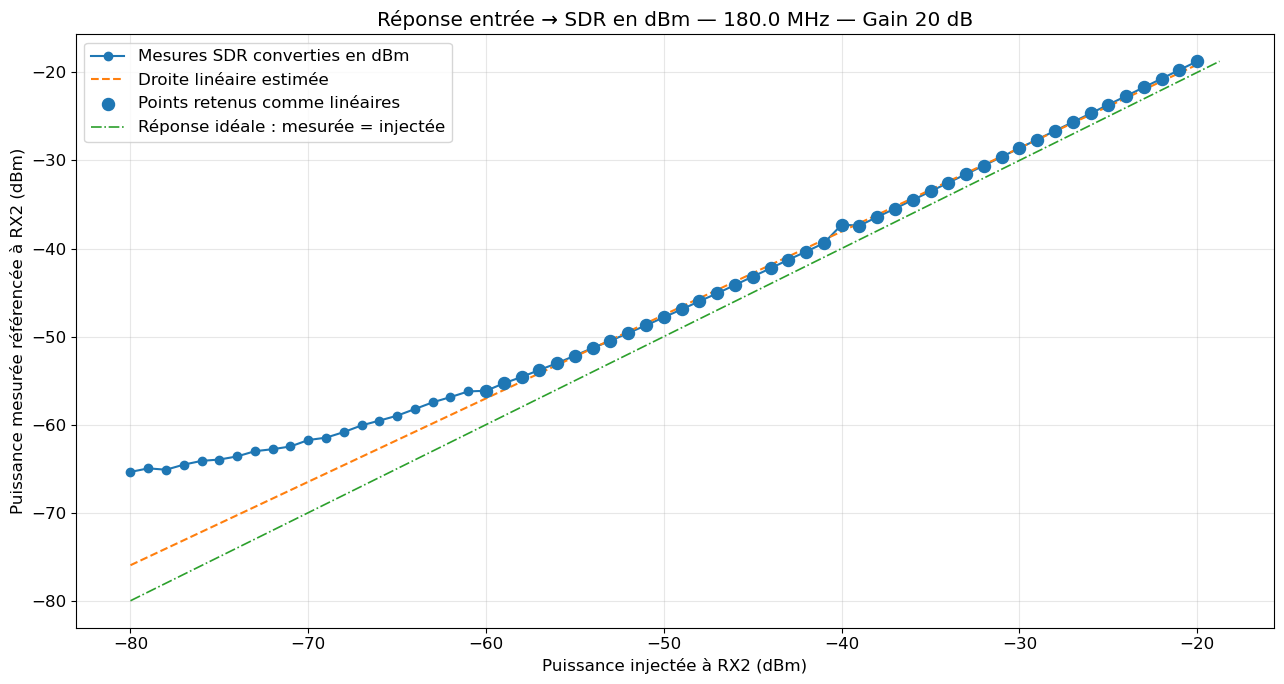

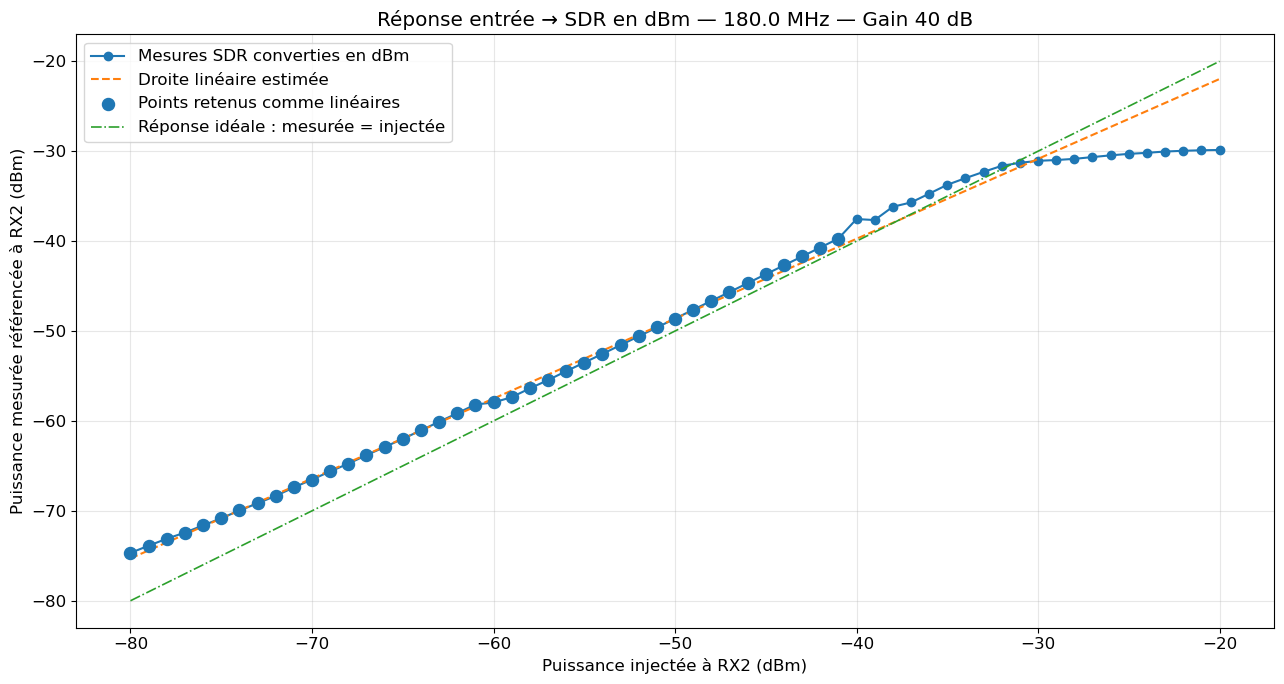

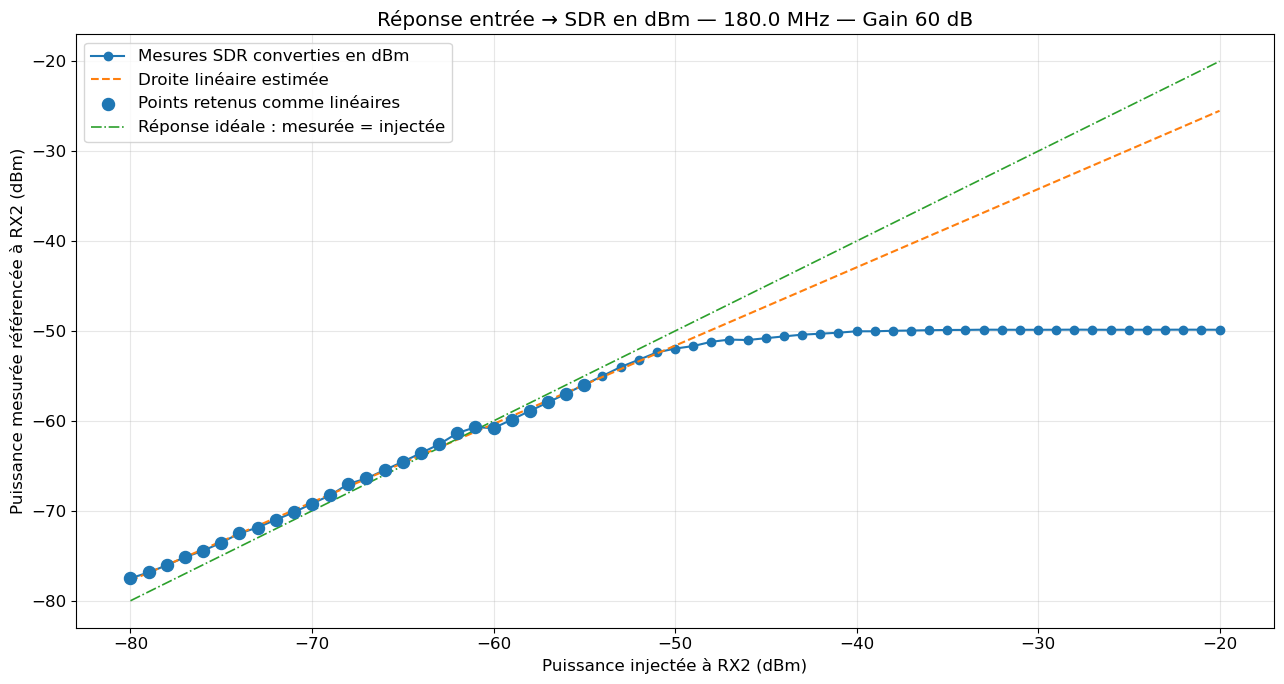

In [11]:
#!/usr/bin/env python3
from __future__ import annotations

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# 1) CONFIGURATION
# ============================================================

DATA_DIR = Path("/home/yousef/b200_dynamic_range_max_pulses_BigRange/")

POINTS_CSV = (
    DATA_DIR
    / "dynamic_range_max_aggregated_points.csv"
)

SUMMARY_CSV = (
    DATA_DIR
    / "dynamic_range_max_summary.csv"
)

OUTPUT_CSV = (
    DATA_DIR
    / "dynamic_range_linear_results.csv"
)

DETAILED_OUTPUT_CSV = (
    DATA_DIR
    / "dynamic_range_linear_detailed_points.csv"
)

# Fichier de calibration UHD RX2
CAL_FILE = (
    Path.home()
    / "b200_calibration_results"
    / "rx2_complete_100MHz_2GHz.pickle"
)


# ------------------------------------------------------------
# Gain à traiter
# ------------------------------------------------------------

# None : traiter tous les gains disponibles.
# Exemple : SELECTED_GAIN = 40.0
SELECTED_GAIN: float | None = None


# ------------------------------------------------------------
# Critères de détection et de linéarité
# ------------------------------------------------------------

# Le signal doit être au moins 6 dB au-dessus du bruit.
MIN_SNR_DB = 6.0

# Pour construire la première droite, on garde les points
# suffisamment éloignés du bruit.
LINEAR_FIT_MIN_SNR_DB = 12.0

# On ne construit pas la droite initiale avec des points
# trop proches de la saturation numérique.
LINEAR_FIT_MAX_DBFS = -12.0

# Écart maximal autorisé par rapport à la droite linéaire.
MAX_LINEARITY_ERROR_DB = 1.0

# Limite numérique maximale autorisée.
# Un point supérieur à -3 dBFS est considéré trop proche
# de la saturation.
MAX_ALLOWED_DBFS = -3.0

# Nombre minimal de points consécutifs pour accepter
# une zone linéaire.
MIN_LINEAR_POINTS = 3

# Une chaîne linéaire doit avoir une pente proche de 1 :
# +1 dB injecté doit produire environ +1 dB mesuré.
MIN_ACCEPTED_SLOPE = 0.85
MAX_ACCEPTED_SLOPE = 1.15


# ============================================================
# 2) OUTILS DE VÉRIFICATION
# ============================================================

def require_columns(
    dataframe: pd.DataFrame,
    required_columns: list[str],
    dataframe_name: str,
) -> None:
    """Vérifie la présence des colonnes nécessaires."""

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Colonnes manquantes dans {dataframe_name} : "
            + ", ".join(missing_columns)
        )


# ============================================================
# 3) CHARGEMENT DES MESURES
# ============================================================

def load_measurement_data() -> tuple[
    pd.DataFrame,
    pd.DataFrame,
]:
    """Charge et nettoie les deux CSV de mesure."""

    for path in [POINTS_CSV, SUMMARY_CSV]:
        if not path.exists():
            raise FileNotFoundError(
                f"Fichier introuvable : {path.resolve()}"
            )

    points_df = pd.read_csv(POINTS_CSV)
    summary_df = pd.read_csv(SUMMARY_CSV)

    points_required = [
        "frequency_mhz",
        "gain_db",
        "input_rx2_dbm",
        "max_dbfs",
    ]

    summary_required = [
        "frequency_mhz",
        "gain_db",
        "noise_max_dbfs",
    ]

    require_columns(
        points_df,
        points_required,
        POINTS_CSV.name,
    )

    require_columns(
        summary_df,
        summary_required,
        SUMMARY_CSV.name,
    )

    for column in points_required:
        points_df[column] = pd.to_numeric(
            points_df[column],
            errors="coerce",
        )

    for column in summary_required:
        summary_df[column] = pd.to_numeric(
            summary_df[column],
            errors="coerce",
        )

    points_df = points_df.dropna(
        subset=points_required
    ).copy()

    summary_df = summary_df.dropna(
        subset=summary_required
    ).copy()

    if SELECTED_GAIN is not None:
        points_df = points_df[
            np.isclose(
                points_df["gain_db"],
                SELECTED_GAIN,
                atol=0.1,
            )
        ].copy()

        summary_df = summary_df[
            np.isclose(
                summary_df["gain_db"],
                SELECTED_GAIN,
                atol=0.1,
            )
        ].copy()

    if points_df.empty:
        raise RuntimeError(
            "Aucun point de mesure disponible."
        )

    if summary_df.empty:
        raise RuntimeError(
            "Aucune mesure de bruit disponible."
        )

    return points_df, summary_df


# ============================================================
# 4) CHARGEMENT DE LA CALIBRATION RX2
# ============================================================

def load_calibration(
    path: Path,
) -> dict[float, dict[float, float]]:
    """
    Charge la calibration UHD sous la forme :

        calibration[frequency_hz][gain_db] = reference_db
    """

    if not path.exists():
        raise FileNotFoundError(
            f"Fichier de calibration introuvable : {path}"
        )

    with path.open("rb") as file:
        raw_calibration = pickle.load(file)

    try:
        rx2_table = raw_calibration[0]["RX2"]
    except (KeyError, IndexError, TypeError) as error:
        raise RuntimeError(
            "Structure inattendue dans le fichier de calibration. "
            'Structure attendue : raw_calibration[0]["RX2"].'
        ) from error

    calibration = {
        float(frequency_hz): {
            float(gain_db): float(reference_db)
            for gain_db, reference_db
            in gain_table.items()
        }
        for frequency_hz, gain_table
        in rx2_table.items()
    }

    if not calibration:
        raise RuntimeError(
            "La table de calibration RX2 est vide."
        )

    return calibration


def reference_at_frequency(
    calibration: dict[float, dict[float, float]],
    frequency_hz: float,
    calibrated_gain_db: float,
) -> float:
    """
    Retourne la référence pour un gain calibré donné.

    Une interpolation est effectuée selon la fréquence.
    """

    points = []

    for calibrated_frequency_hz, gain_table in calibration.items():
        matching_gain = None

        for available_gain_db in gain_table:
            if np.isclose(
                available_gain_db,
                calibrated_gain_db,
                atol=1e-6,
            ):
                matching_gain = available_gain_db
                break

        if matching_gain is not None:
            points.append(
                (
                    float(calibrated_frequency_hz),
                    float(gain_table[matching_gain]),
                )
            )

    if not points:
        raise ValueError(
            f"Aucune calibration disponible pour le gain "
            f"{calibrated_gain_db:.1f} dB."
        )

    points.sort(key=lambda point: point[0])

    frequencies_hz = np.asarray(
        [point[0] for point in points],
        dtype=float,
    )

    references_db = np.asarray(
        [point[1] for point in points],
        dtype=float,
    )

    if frequency_hz < frequencies_hz[0]:
        raise ValueError(
            f"Fréquence {frequency_hz / 1e6:.1f} MHz inférieure "
            f"à la fréquence calibrée minimale "
            f"{frequencies_hz[0] / 1e6:.1f} MHz."
        )

    if frequency_hz > frequencies_hz[-1]:
        raise ValueError(
            f"Fréquence {frequency_hz / 1e6:.1f} MHz supérieure "
            f"à la fréquence calibrée maximale "
            f"{frequencies_hz[-1] / 1e6:.1f} MHz."
        )

    return float(
        np.interp(
            frequency_hz,
            frequencies_hz,
            references_db,
        )
    )


def get_calibration_reference(
    calibration: dict[float, dict[float, float]],
    frequency_hz: float,
    gain_db: float,
) -> float:
    """
    Retourne la référence C(f,G).

    Une interpolation est effectuée selon la fréquence
    et éventuellement selon le gain.
    """

    available_gains = sorted(
        {
            float(calibrated_gain_db)
            for gain_table in calibration.values()
            for calibrated_gain_db in gain_table
        }
    )

    if not available_gains:
        raise RuntimeError(
            "Aucun gain trouvé dans la calibration."
        )

    if gain_db < available_gains[0]:
        raise ValueError(
            f"Gain {gain_db:.1f} dB inférieur au gain calibré "
            f"minimal {available_gains[0]:.1f} dB."
        )

    if gain_db > available_gains[-1]:
        raise ValueError(
            f"Gain {gain_db:.1f} dB supérieur au gain calibré "
            f"maximal {available_gains[-1]:.1f} dB."
        )

    # Gain exactement disponible
    for calibrated_gain_db in available_gains:
        if np.isclose(
            gain_db,
            calibrated_gain_db,
            atol=1e-6,
        ):
            return reference_at_frequency(
                calibration=calibration,
                frequency_hz=frequency_hz,
                calibrated_gain_db=calibrated_gain_db,
            )

    # Interpolation entre deux gains
    lower_gain_db = max(
        calibrated_gain_db
        for calibrated_gain_db in available_gains
        if calibrated_gain_db < gain_db
    )

    upper_gain_db = min(
        calibrated_gain_db
        for calibrated_gain_db in available_gains
        if calibrated_gain_db > gain_db
    )

    lower_reference_db = reference_at_frequency(
        calibration=calibration,
        frequency_hz=frequency_hz,
        calibrated_gain_db=lower_gain_db,
    )

    upper_reference_db = reference_at_frequency(
        calibration=calibration,
        frequency_hz=frequency_hz,
        calibrated_gain_db=upper_gain_db,
    )

    return float(
        np.interp(
            gain_db,
            [lower_gain_db, upper_gain_db],
            [lower_reference_db, upper_reference_db],
        )
    )


# ============================================================
# 5) NIVEAU DE BRUIT
# ============================================================

def get_noise_floor_dbfs(
    summary_df: pd.DataFrame,
    frequency_mhz: float,
    gain_db: float,
) -> float:
    """Retourne le niveau de bruit pour une fréquence et un gain."""

    matching_rows = summary_df[
        np.isclose(
            summary_df["frequency_mhz"],
            frequency_mhz,
            atol=1e-6,
        )
        & np.isclose(
            summary_df["gain_db"],
            gain_db,
            atol=0.1,
        )
    ]

    if matching_rows.empty:
        return np.nan

    return float(
        matching_rows["noise_max_dbfs"].median()
    )


# ============================================================
# 6) RÉGRESSION LINÉAIRE
# ============================================================

def linear_regression(
    dataframe: pd.DataFrame,
) -> dict[str, float]:
    """
    Régression :

        max_dbfs =
            slope * input_rx2_dbm
            + intercept
    """

    if len(dataframe) < MIN_LINEAR_POINTS:
        return {
            "slope": np.nan,
            "intercept": np.nan,
            "rmse_db": np.nan,
            "r_squared": np.nan,
        }

    x = dataframe[
        "input_rx2_dbm"
    ].to_numpy(dtype=float)

    y = dataframe[
        "max_dbfs"
    ].to_numpy(dtype=float)

    if np.ptp(x) <= 0:
        return {
            "slope": np.nan,
            "intercept": np.nan,
            "rmse_db": np.nan,
            "r_squared": np.nan,
        }

    slope, intercept = np.polyfit(
        x,
        y,
        1,
    )

    predicted = slope * x + intercept
    residuals = y - predicted

    rmse_db = float(
        np.sqrt(
            np.mean(residuals**2)
        )
    )

    ss_res = float(
        np.sum(residuals**2)
    )

    ss_tot = float(
        np.sum(
            (y - np.mean(y)) ** 2
        )
    )

    if ss_tot > 0:
        r_squared = float(
            1.0 - ss_res / ss_tot
        )
    else:
        r_squared = np.nan

    return {
        "slope": float(slope),
        "intercept": float(intercept),
        "rmse_db": rmse_db,
        "r_squared": r_squared,
    }


# ============================================================
# 7) PLUS LONGUE ZONE CONTINUE
# ============================================================

def longest_contiguous_true_region(
    dataframe: pd.DataFrame,
    boolean_column: str,
) -> pd.DataFrame:
    """
    Retourne la plus longue suite continue de lignes True.

    Le tableau doit être trié par puissance injectée.
    """

    dataframe = dataframe.reset_index(drop=True)

    values = (
        dataframe[boolean_column]
        .fillna(False)
        .astype(bool)
        .to_numpy()
    )

    best_start: int | None = None
    best_end: int | None = None
    current_start: int | None = None

    for index, is_valid in enumerate(values):
        if is_valid:
            if current_start is None:
                current_start = index
        else:
            if current_start is not None:
                current_end = index - 1

                if best_start is None:
                    best_start = current_start
                    best_end = current_end
                else:
                    current_length = (
                        current_end - current_start + 1
                    )

                    best_length = (
                        best_end - best_start + 1
                    )

                    if current_length > best_length:
                        best_start = current_start
                        best_end = current_end

                current_start = None

    # Zone allant jusqu'au dernier point
    if current_start is not None:
        current_end = len(dataframe) - 1

        if best_start is None:
            best_start = current_start
            best_end = current_end
        else:
            current_length = (
                current_end - current_start + 1
            )

            best_length = (
                best_end - best_start + 1
            )

            if current_length > best_length:
                best_start = current_start
                best_end = current_end

    if best_start is None or best_end is None:
        return dataframe.iloc[0:0].copy()

    return dataframe.iloc[
        best_start:
        best_end + 1
    ].copy()


# ============================================================
# 8) CALCUL POUR UNE FRÉQUENCE ET UN GAIN
# ============================================================

def calculate_case_dynamic_range(
    case_df: pd.DataFrame,
    noise_dbfs: float,
    frequency_mhz: float,
    gain_db: float,
    calibration_reference_db: float,
) -> tuple[dict, pd.DataFrame]:
    """
    Calcule la plus longue zone linéaire exploitable.
    """

    # Médiane si plusieurs mesures existent pour une même entrée
    case_df = (
        case_df.groupby(
            "input_rx2_dbm",
            as_index=False,
        )
        .agg(
            max_dbfs=("max_dbfs", "median"),
            number_of_points=("max_dbfs", "size"),
        )
        .sort_values("input_rx2_dbm")
        .reset_index(drop=True)
    )

    # Conversion des mesures en dBm
    case_df["measured_dbm"] = (
        case_df["max_dbfs"]
        + calibration_reference_db
    )

    noise_dbm = (
        noise_dbfs
        + calibration_reference_db
    )

    case_df["snr_db"] = (
        case_df["max_dbfs"]
        - noise_dbfs
    )

    # --------------------------------------------------------
    # Première régression
    # --------------------------------------------------------

    initial_candidates = case_df[
        (
            case_df["snr_db"]
            >= LINEAR_FIT_MIN_SNR_DB
        )
        & (
            case_df["max_dbfs"]
            <= LINEAR_FIT_MAX_DBFS
        )
    ].copy()

    initial_fit = linear_regression(
        initial_candidates
    )

    initial_slope = initial_fit["slope"]
    initial_intercept = initial_fit["intercept"]

    # Colonnes initialisées
    case_df["predicted_dbfs"] = np.nan
    case_df["predicted_dbm"] = np.nan
    case_df["linearity_error_db"] = np.nan
    case_df["compression_db"] = np.nan

    case_df["is_above_noise"] = False
    case_df["is_below_saturation"] = False
    case_df["is_close_to_line"] = False

    case_df["is_linear_initial"] = False
    case_df["is_linear_final"] = False

    minimum_linear_dbm = np.nan
    maximum_linear_dbm = np.nan

    minimum_linear_measured_dbm = np.nan
    maximum_linear_measured_dbm = np.nan

    minimum_linear_dbfs = np.nan
    maximum_linear_dbfs = np.nan

    dynamic_range_db = np.nan

    final_slope = np.nan
    final_intercept = np.nan
    final_rmse_db = np.nan
    final_r_squared = np.nan

    number_of_linear_points = 0

    slope_is_valid = bool(
        np.isfinite(initial_slope)
        and MIN_ACCEPTED_SLOPE
        <= initial_slope
        <= MAX_ACCEPTED_SLOPE
    )

    if slope_is_valid:
        case_df["predicted_dbfs"] = (
            initial_slope
            * case_df["input_rx2_dbm"]
            + initial_intercept
        )

        case_df["predicted_dbm"] = (
            case_df["predicted_dbfs"]
            + calibration_reference_db
        )

        case_df["linearity_error_db"] = np.abs(
            case_df["max_dbfs"]
            - case_df["predicted_dbfs"]
        )

        case_df["compression_db"] = (
            case_df["predicted_dbfs"]
            - case_df["max_dbfs"]
        )

        case_df["is_above_noise"] = (
            case_df["snr_db"]
            >= MIN_SNR_DB
        )

        case_df["is_below_saturation"] = (
            case_df["max_dbfs"]
            <= MAX_ALLOWED_DBFS
        )

        case_df["is_close_to_line"] = (
            case_df["linearity_error_db"]
            <= MAX_LINEARITY_ERROR_DB
        )

        case_df["is_linear_initial"] = (
            case_df["is_above_noise"]
            & case_df["is_below_saturation"]
            & case_df["is_close_to_line"]
        )

        initial_linear_region = (
            longest_contiguous_true_region(
                case_df,
                "is_linear_initial",
            )
        )

        # ----------------------------------------------------
        # Régression finale sur la zone linéaire détectée
        # ----------------------------------------------------

        if len(initial_linear_region) >= MIN_LINEAR_POINTS:
            final_fit = linear_regression(
                initial_linear_region
            )

            final_slope = final_fit["slope"]
            final_intercept = final_fit["intercept"]
            final_rmse_db = final_fit["rmse_db"]
            final_r_squared = final_fit["r_squared"]

            final_slope_is_valid = bool(
                np.isfinite(final_slope)
                and MIN_ACCEPTED_SLOPE
                <= final_slope
                <= MAX_ACCEPTED_SLOPE
            )

            if final_slope_is_valid:
                case_df["predicted_dbfs"] = (
                    final_slope
                    * case_df["input_rx2_dbm"]
                    + final_intercept
                )

                case_df["predicted_dbm"] = (
                    case_df["predicted_dbfs"]
                    + calibration_reference_db
                )

                case_df["linearity_error_db"] = np.abs(
                    case_df["max_dbfs"]
                    - case_df["predicted_dbfs"]
                )

                case_df["compression_db"] = (
                    case_df["predicted_dbfs"]
                    - case_df["max_dbfs"]
                )

                case_df["is_close_to_line"] = (
                    case_df["linearity_error_db"]
                    <= MAX_LINEARITY_ERROR_DB
                )

                case_df["is_linear_final"] = (
                    case_df["is_above_noise"]
                    & case_df["is_below_saturation"]
                    & case_df["is_close_to_line"]
                )

                final_linear_region = (
                    longest_contiguous_true_region(
                        case_df,
                        "is_linear_final",
                    )
                )

                if len(final_linear_region) >= MIN_LINEAR_POINTS:
                    minimum_row = final_linear_region.iloc[0]
                    maximum_row = final_linear_region.iloc[-1]

                    # Limites en puissance injectée
                    minimum_linear_dbm = float(
                        minimum_row["input_rx2_dbm"]
                    )

                    maximum_linear_dbm = float(
                        maximum_row["input_rx2_dbm"]
                    )

                    # Limites mesurées et converties en dBm
                    minimum_linear_measured_dbm = float(
                        minimum_row["measured_dbm"]
                    )

                    maximum_linear_measured_dbm = float(
                        maximum_row["measured_dbm"]
                    )

                    minimum_linear_dbfs = float(
                        minimum_row["max_dbfs"]
                    )

                    maximum_linear_dbfs = float(
                        maximum_row["max_dbfs"]
                    )

                    dynamic_range_db = float(
                        maximum_linear_dbm
                        - minimum_linear_dbm
                    )

                    number_of_linear_points = int(
                        len(final_linear_region)
                    )

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    below_noise_df = case_df[
        case_df["snr_db"] < MIN_SNR_DB
    ]

    if not below_noise_df.empty:
        last_below_detection_dbm = float(
            below_noise_df.iloc[-1]["input_rx2_dbm"]
        )
    else:
        last_below_detection_dbm = np.nan

    compressed_df = case_df[
        case_df["compression_db"]
        > MAX_LINEARITY_ERROR_DB
    ]

    if not compressed_df.empty:
        first_compressed_dbm = float(
            compressed_df.iloc[0]["input_rx2_dbm"]
        )
    else:
        first_compressed_dbm = np.nan

    saturated_df = case_df[
        case_df["max_dbfs"]
        > MAX_ALLOWED_DBFS
    ]

    if not saturated_df.empty:
        first_saturated_dbm = float(
            saturated_df.iloc[0]["input_rx2_dbm"]
        )
    else:
        first_saturated_dbm = np.nan

    result = {
        "frequency_mhz": float(frequency_mhz),
        "gain_db": float(gain_db),

        "calibration_reference_db": float(
            calibration_reference_db
        ),

        "noise_max_dbfs": float(noise_dbfs),
        "noise_max_dbm": float(noise_dbm),

        "minimum_linear_input_dbm": (
            minimum_linear_dbm
        ),

        "maximum_linear_input_dbm": (
            maximum_linear_dbm
        ),

        "minimum_linear_measured_dbm": (
            minimum_linear_measured_dbm
        ),

        "maximum_linear_measured_dbm": (
            maximum_linear_measured_dbm
        ),

        "minimum_linear_dbfs": (
            minimum_linear_dbfs
        ),

        "maximum_linear_dbfs": (
            maximum_linear_dbfs
        ),

        "dynamic_range_db": (
            dynamic_range_db
        ),

        "linear_fit_slope": (
            final_slope
        ),

        "linear_fit_intercept_dbfs": (
            final_intercept
        ),

        "linear_fit_rmse_db": (
            final_rmse_db
        ),

        "linear_fit_r_squared": (
            final_r_squared
        ),

        "number_of_input_levels": int(
            len(case_df)
        ),

        "number_of_linear_points": (
            number_of_linear_points
        ),

        "last_point_below_detection_dbm": (
            last_below_detection_dbm
        ),

        "first_compressed_input_dbm": (
            first_compressed_dbm
        ),

        "first_saturated_input_dbm": (
            first_saturated_dbm
        ),
    }

    case_df["frequency_mhz"] = float(
        frequency_mhz
    )

    case_df["gain_db"] = float(
        gain_db
    )

    case_df["calibration_reference_db"] = float(
        calibration_reference_db
    )

    case_df["noise_max_dbfs"] = float(
        noise_dbfs
    )

    case_df["noise_max_dbm"] = float(
        noise_dbm
    )

    return result, case_df


# ============================================================
# 9) CALCUL POUR TOUS LES CAS
# ============================================================

def calculate_all_dynamic_ranges(
    points_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    calibration: dict[float, dict[float, float]],
) -> tuple[pd.DataFrame, pd.DataFrame]:

    results = []
    detailed_results = []

    grouped = points_df.groupby(
        ["gain_db", "frequency_mhz"]
    )

    for (
        gain_db,
        frequency_mhz,
    ), case_df in grouped:

        noise_dbfs = get_noise_floor_dbfs(
            summary_df=summary_df,
            frequency_mhz=float(frequency_mhz),
            gain_db=float(gain_db),
        )

        if not np.isfinite(noise_dbfs):
            print(
                f"Attention : bruit introuvable pour "
                f"{frequency_mhz:.1f} MHz, "
                f"gain {gain_db:.1f} dB."
            )
            continue

        try:
            calibration_reference_db = (
                get_calibration_reference(
                    calibration=calibration,
                    frequency_hz=float(
                        frequency_mhz
                    ) * 1e6,
                    gain_db=float(gain_db),
                )
            )
        except ValueError as error:
            print(
                f"Calibration indisponible pour "
                f"{frequency_mhz:.1f} MHz, "
                f"gain {gain_db:.1f} dB : {error}"
            )
            continue

        result, detailed_case_df = (
            calculate_case_dynamic_range(
                case_df=case_df,
                noise_dbfs=noise_dbfs,
                frequency_mhz=float(frequency_mhz),
                gain_db=float(gain_db),
                calibration_reference_db=(
                    calibration_reference_db
                ),
            )
        )

        results.append(result)
        detailed_results.append(detailed_case_df)

    results_df = pd.DataFrame(results)

    if results_df.empty:
        raise RuntimeError(
            "Aucune dynamique n'a pu être calculée."
        )

    results_df = results_df.sort_values(
        ["gain_db", "frequency_mhz"]
    ).reset_index(drop=True)

    if detailed_results:
        detailed_df = pd.concat(
            detailed_results,
            ignore_index=True,
        )
    else:
        detailed_df = pd.DataFrame()

    return results_df, detailed_df


# ============================================================
# 10) AFFICHAGE TEXTE
# ============================================================

def print_results(
    results_df: pd.DataFrame,
) -> None:

    print()
    print("=" * 135)
    print("DYNAMIQUE LINÉAIRE DE LA SDR")
    print("=" * 135)

    columns = [
        "frequency_mhz",
        "gain_db",
        "noise_max_dbm",
        "minimum_linear_input_dbm",
        "maximum_linear_input_dbm",
        "dynamic_range_db",
        "linear_fit_slope",
        "linear_fit_r_squared",
        "number_of_linear_points",
    ]

    print(
        results_df[columns].to_string(
            index=False,
            float_format=lambda value: f"{value:.2f}",
        )
    )

    print()
    print(
        "Dynamique = puissance d'entrée maximale linéaire "
        "- puissance d'entrée minimale linéaire"
    )

    print(
        f"SNR minimal : {MIN_SNR_DB:.1f} dB"
    )

    print(
        f"Erreur maximale de linéarité : "
        f"{MAX_LINEARITY_ERROR_DB:.1f} dB"
    )

    print(
        f"Limite numérique : "
        f"{MAX_ALLOWED_DBFS:.1f} dBFS"
    )

    print(
        f"Pente acceptée : "
        f"{MIN_ACCEPTED_SLOPE:.2f} à "
        f"{MAX_ACCEPTED_SLOPE:.2f}"
    )


# ============================================================
# 11) GRAPHE DE LA DYNAMIQUE
# ============================================================

def plot_dynamic_range(
    results_df: pd.DataFrame,
) -> None:

    plt.figure(figsize=(15, 7))

    for gain_db in sorted(
        results_df["gain_db"].dropna().unique()
    ):
        gain_df = results_df[
            np.isclose(
                results_df["gain_db"],
                gain_db,
                atol=0.1,
            )
        ].dropna(
            subset=["dynamic_range_db"]
        )

        plt.plot(
            gain_df["frequency_mhz"],
            gain_df["dynamic_range_db"],
            marker="o",
            linewidth=1.5,
            label=f"Gain {gain_db:.0f} dB",
        )

    plt.title(
        "Dynamique linéaire exploitable de la SDR"
    )

    plt.xlabel("Fréquence (MHz)")
    plt.ylabel("Dynamique linéaire (dB)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 12) LIMITES MIN/MAX DE LA ZONE LINÉAIRE
# ============================================================

def plot_linear_limits(
    results_df: pd.DataFrame,
) -> None:

    for gain_db in sorted(
        results_df["gain_db"].dropna().unique()
    ):
        gain_df = results_df[
            np.isclose(
                results_df["gain_db"],
                gain_db,
                atol=0.1,
            )
        ].sort_values("frequency_mhz")

        plt.figure(figsize=(15, 7))

        plt.plot(
            gain_df["frequency_mhz"],
            gain_df["minimum_linear_input_dbm"],
            marker="o",
            linewidth=1.5,
            label="Puissance minimale linéaire",
        )

        plt.plot(
            gain_df["frequency_mhz"],
            gain_df["maximum_linear_input_dbm"],
            marker="o",
            linewidth=1.5,
            label="Puissance maximale linéaire",
        )

        plt.title(
            "Limites de la zone linéaire — "
            f"Gain RX = {gain_db:.0f} dB"
        )

        plt.xlabel("Fréquence (MHz)")
        plt.ylabel("Puissance injectée à RX2 (dBm)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# ============================================================
# 13) RÉPONSE ENTRÉE → SDR EN dBm
# ============================================================

def plot_example_response_dbm(
    detailed_df: pd.DataFrame,
    results_df: pd.DataFrame,
) -> None:

    for gain_db in sorted(
        results_df["gain_db"].dropna().unique()
    ):
        valid_results = results_df[
            np.isclose(
                results_df["gain_db"],
                gain_db,
                atol=0.1,
            )
            & results_df["dynamic_range_db"].notna()
        ]

        if valid_results.empty:
            continue

        result_row = valid_results.iloc[0]

        frequency_mhz = float(
            result_row["frequency_mhz"]
        )

        case_df = detailed_df[
            np.isclose(
                detailed_df["gain_db"],
                gain_db,
                atol=0.1,
            )
            & np.isclose(
                detailed_df["frequency_mhz"],
                frequency_mhz,
                atol=1e-6,
            )
        ].sort_values(
            "input_rx2_dbm"
        ).copy()

        if case_df.empty:
            continue

        plt.figure(figsize=(13, 7))

        # 1. Mesures SDR converties en dBm
        plt.plot(
            case_df["input_rx2_dbm"],
            case_df["measured_dbm"],
            marker="o",
            linewidth=1.5,
            label="Mesures SDR converties en dBm",
        )

        # 2. Droite linéaire estimée
        valid_prediction = (
            case_df["predicted_dbm"].notna()
        )

        if valid_prediction.any():
            plt.plot(
                case_df.loc[
                    valid_prediction,
                    "input_rx2_dbm",
                ],
                case_df.loc[
                    valid_prediction,
                    "predicted_dbm",
                ],
                linestyle="--",
                linewidth=1.5,
                label="Droite linéaire estimée",
            )

        # 3. Points retenus comme linéaires
        linear_points = case_df[
            case_df["is_linear_final"]
        ]

        if not linear_points.empty:
            plt.scatter(
                linear_points["input_rx2_dbm"],
                linear_points["measured_dbm"],
                s=75,
                label="Points retenus comme linéaires",
                zorder=5,
            )

        # 4. Réponse idéale : y = x
        all_values = np.concatenate(
            [
                case_df["input_rx2_dbm"].to_numpy(dtype=float),
                case_df["measured_dbm"].to_numpy(dtype=float),
            ]
        )

        minimum_axis = float(
            np.nanmin(all_values)
        )

        maximum_axis = float(
            np.nanmax(all_values)
        )

        plt.plot(
            [minimum_axis, maximum_axis],
            [minimum_axis, maximum_axis],
            linestyle="-.",
            linewidth=1.2,
            label="Réponse idéale : mesurée = injectée",
        )

        plt.title(
            f"Réponse entrée → SDR en dBm — "
            f"{frequency_mhz:.1f} MHz — "
            f"Gain {gain_db:.0f} dB"
        )

        plt.xlabel(
            "Puissance injectée à RX2 (dBm)"
        )

        plt.ylabel(
            "Puissance mesurée référencée à RX2 (dBm)"
        )

        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

# ============================================================
# 14) MAIN
# ============================================================

def main() -> None:

    print("Chargement des mesures...")

    points_df, summary_df = (
        load_measurement_data()
    )

    print(
        f"Nombre de points de mesure : "
        f"{len(points_df)}"
    )

    print(
        "Gains trouvés dans les mesures : "
        f"{sorted(points_df['gain_db'].unique())}"
    )

    print()
    print("Chargement de la calibration RX2...")

    calibration = load_calibration(
        CAL_FILE
    )

    calibrated_frequencies_hz = sorted(
        calibration.keys()
    )

    calibrated_gains_db = sorted(
        {
            gain_db
            for gain_table in calibration.values()
            for gain_db in gain_table
        }
    )

    print(
        "Plage de calibration : "
        f"{calibrated_frequencies_hz[0] / 1e6:.1f} MHz "
        f"à "
        f"{calibrated_frequencies_hz[-1] / 1e6:.1f} MHz"
    )

    print(
        f"Gains calibrés : "
        f"{calibrated_gains_db}"
    )

    results_df, detailed_df = (
        calculate_all_dynamic_ranges(
            points_df=points_df,
            summary_df=summary_df,
            calibration=calibration,
        )
    )

    results_df.to_csv(
        OUTPUT_CSV,
        index=False,
    )

    detailed_df.to_csv(
        DETAILED_OUTPUT_CSV,
        index=False,
    )

    print_results(
        results_df
    )

    print()
    print(
        f"Résumé enregistré dans : "
        f"{OUTPUT_CSV.resolve()}"
    )

    print(
        f"Détails enregistrés dans : "
        f"{DETAILED_OUTPUT_CSV.resolve()}"
    )

    plot_dynamic_range(
        results_df
    )

    plot_linear_limits(
        results_df
    )

    plot_example_response_dbm(
        detailed_df=detailed_df,
        results_df=results_df,
    )


if __name__ == "__main__":
    main()

Droite estimée : y = 0.8946 x -3.5950


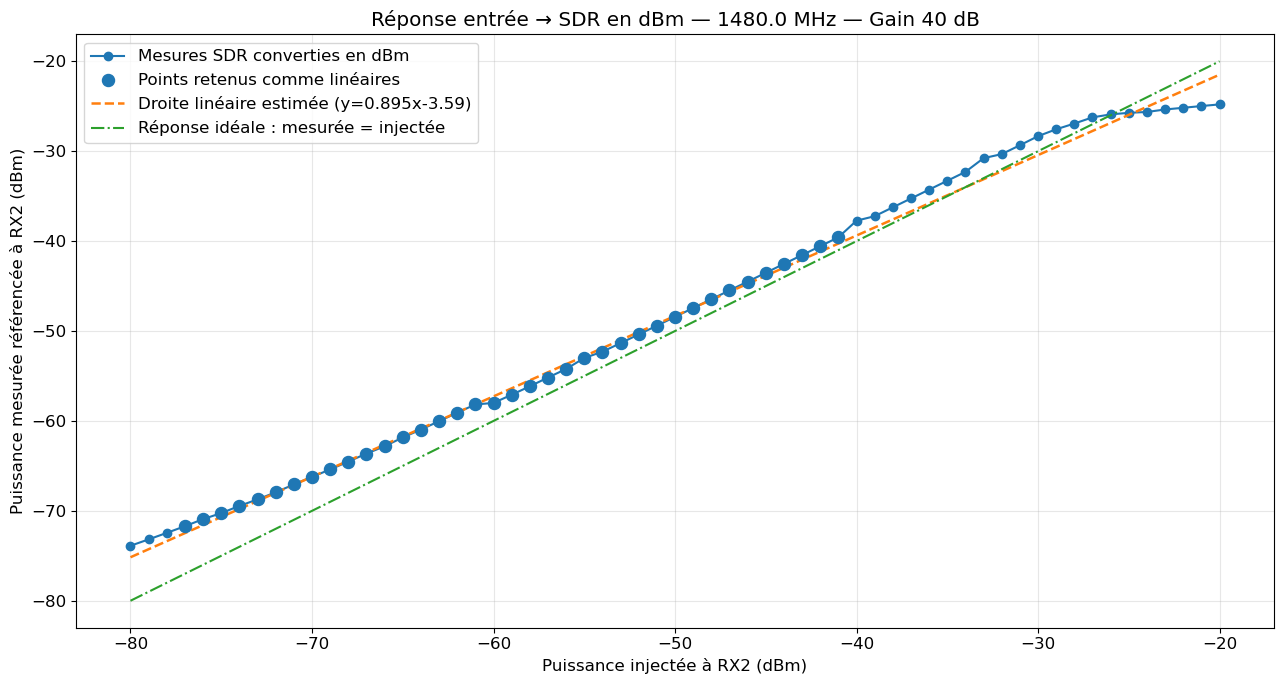

In [16]:
#!/usr/bin/env python3

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = Path("./Dyn_Files/b200_dynamic_range_max_pulses_BigRange")

DETAILED_CSV = (
    DATA_DIR
    / "dynamic_range_linear_detailed_points.csv"
)

GAIN_DB = 40.0
FREQUENCY_MHZ = 1480.0


# ============================================================
# CHARGEMENT DU FICHIER
# ============================================================

if not DETAILED_CSV.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {DETAILED_CSV.resolve()}"
    )

df = pd.read_csv(DETAILED_CSV)


# ============================================================
# VÉRIFICATION DES COLONNES
# ============================================================

required_columns = [
    "gain_db",
    "frequency_mhz",
    "input_rx2_dbm",
    "measured_dbm",
    "is_linear_final",
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "Colonnes manquantes : "
        + ", ".join(missing_columns)
    )


# Conversion numérique
numeric_columns = [
    "gain_db",
    "frequency_mhz",
    "input_rx2_dbm",
    "measured_dbm",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )


# Conversion fiable de la colonne booléenne
df["is_linear_final"] = (
    df["is_linear_final"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1", "yes"])
)


# ============================================================
# SÉLECTION DU GAIN 76 dB ET DE 100 MHz
# ============================================================

case_df = df[
    np.isclose(
        df["gain_db"],
        GAIN_DB,
        atol=0.1,
    )
    & np.isclose(
        df["frequency_mhz"],
        FREQUENCY_MHZ,
        atol=1e-6,
    )
].copy()

case_df = case_df.dropna(
    subset=[
        "input_rx2_dbm",
        "measured_dbm",
    ]
).sort_values(
    "input_rx2_dbm"
).reset_index(drop=True)


if case_df.empty:
    print(
        f"Aucune donnée trouvée pour le gain "
        f"{GAIN_DB:.0f} dB à "
        f"{FREQUENCY_MHZ:.1f} MHz."
    )

    print(
        "\nGains disponibles :",
        sorted(df["gain_db"].dropna().unique()),
    )

    gain_76_df = df[
        np.isclose(
            df["gain_db"],
            GAIN_DB,
            atol=0.1,
        )
    ]

    if not gain_76_df.empty:
        print(
            "Fréquences disponibles au gain 76 dB :",
            sorted(
                gain_76_df[
                    "frequency_mhz"
                ].dropna().unique()
            ),
        )

    raise SystemExit(1)


# ============================================================
# POINTS LINÉAIRES
# ============================================================

linear_points = case_df[
    case_df["is_linear_final"]
].copy()

if len(linear_points) < 2:
    print(
        "Attention : moins de deux points ont été retenus "
        "comme linéaires. Impossible de calculer une droite."
    )


# ============================================================
# TRACÉ
# ============================================================

plt.figure(figsize=(13, 7))


# 1) Mesures SDR converties en dBm
plt.plot(
    case_df["input_rx2_dbm"],
    case_df["measured_dbm"],
    marker="o",
    linewidth=1.5,
    label="Mesures SDR converties en dBm",
)


# 2) Points retenus comme linéaires
if not linear_points.empty:
    plt.scatter(
        linear_points["input_rx2_dbm"],
        linear_points["measured_dbm"],
        s=75,
        label="Points retenus comme linéaires",
        zorder=5,
    )


# 3) Droite linéaire estimée
if len(linear_points) >= 2:

    x_linear = linear_points[
        "input_rx2_dbm"
    ].to_numpy(dtype=float)

    y_linear = linear_points[
        "measured_dbm"
    ].to_numpy(dtype=float)

    slope, intercept = np.polyfit(
        x_linear,
        y_linear,
        1,
    )

    # Droite tracée sur toute la plage d'entrée
    x_fit = np.linspace(
        case_df["input_rx2_dbm"].min(),
        case_df["input_rx2_dbm"].max(),
        200,
    )

    y_fit = (
        slope * x_fit
        + intercept
    )

    plt.plot(
        x_fit,
        y_fit,
        linestyle="--",
        linewidth=1.8,
        label=(
            f"Droite linéaire estimée "
            f"(y={slope:.3f}x{intercept:+.2f})"
        ),
    )

    print(
        f"Droite estimée : "
        f"y = {slope:.4f} x {intercept:+.4f}"
    )


# 4) Réponse idéale : y = x
minimum_axis = float(
    min(
        case_df["input_rx2_dbm"].min(),
        case_df["measured_dbm"].min(),
    )
)

maximum_axis = float(
    max(
        case_df["input_rx2_dbm"].max(),
        case_df["measured_dbm"].max(),
    )
)

plt.plot(
    [minimum_axis, maximum_axis],
    [minimum_axis, maximum_axis],
    linestyle="-.",
    linewidth=1.5,
    label="Réponse idéale : mesurée = injectée",
)


# ============================================================
# MISE EN FORME
# ============================================================

plt.title(
    f"Réponse entrée → SDR en dBm — "
    f"{FREQUENCY_MHZ:.1f} MHz — "
    f"Gain {GAIN_DB:.0f} dB"
)

plt.xlabel(
    "Puissance injectée à RX2 (dBm)"
)

plt.ylabel(
    "Puissance mesurée référencée à RX2 (dBm)"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.legend()
plt.tight_layout()
plt.show()

BASE DE DONNÉES

Fichier : /home/yousef/Documents/testing_scripts/GEVernova/Fi_Wo_Ca_Dy/Files/b200_dynamic_range_max_pulses/dynamic_range_linear_detailed_points.csv

Colonnes disponibles :
 - input_rx2_dbm
 - max_dbfs
 - number_of_points
 - measured_dbm
 - snr_db
 - predicted_dbfs
 - predicted_dbm
 - linearity_error_db
 - compression_db
 - is_above_noise
 - is_below_saturation
 - is_close_to_line
 - is_linear_initial
 - is_linear_final
 - frequency_mhz
 - gain_db
 - calibration_reference_db
 - noise_max_dbfs
 - noise_max_dbm

CALIBRATION B200

Nombre total de points : 6100

Gains disponibles : [0.0, 20.0, 40.0, 60.0, 76.0]

Nombre de fréquences : 20
Plage : 100.0 MHz -> 2000.0 MHz
SKIP : 100.0 MHz | Gain 76 dB | Seulement 0 points linéaires
SKIP : 200.0 MHz | Gain 76 dB | Seulement 0 points linéaires
SKIP : 300.0 MHz | Gain 76 dB | Seulement 0 points linéaires
SKIP : 400.0 MHz | Gain 76 dB | Seulement 0 points linéaires
SKIP : 500.0 MHz | Gain 60 dB | Seulement 0 points linéaires
SKIP 

,frequencies,valid_frequencies,median_r2,median_simple_error_db,median_model_error_db,max_simple_error_db
gain_db,,,,,,
0.0,20,20,0.998346,0.547024,0.282519,2.788392
20.0,20,20,0.999126,0.202384,0.189378,2.257175
40.0,20,19,0.998403,0.540260,0.268415,3.753763
60.0,19,15,0.999162,0.801310,0.177514,2.720356



Table de calibration :


,frequency_mhz,gain_db,n_linear_points,slope_dbfs_per_dbm,intercept_dbfs,r2,reference_dbm,median_abs_error_simple_db,median_abs_error_model_db,valid
0,100.0,0.0,30,0.899042,-7.433379,0.998101,4.300722,0.509651,0.324797,True
1,200.0,0.0,30,0.897840,-7.724697,0.998194,4.524169,0.537694,0.331010,True
2,300.0,0.0,30,0.898688,-7.901077,0.998288,4.709529,0.544748,0.316442,True
3,400.0,0.0,30,0.902827,-7.717016,0.998488,4.694163,0.522069,0.285151,True
4,500.0,0.0,30,0.902026,-7.647714,0.998305,4.591638,0.512097,0.310368,True
...,...,...,...,...,...,...,...,...,...,...
74,1600.0,60.0,29,0.877635,41.819376,0.999278,-49.920747,0.942285,0.152372,True
75,1700.0,60.0,30,0.879239,41.421893,0.999286,-49.325181,1.034690,0.185190,False
76,1800.0,60.0,30,0.876442,40.626397,0.999162,-48.733464,1.129729,0.198072,False
77,1900.0,60.0,31,0.872842,39.738836,0.998957,-47.970157,1.154433,0.170213,False


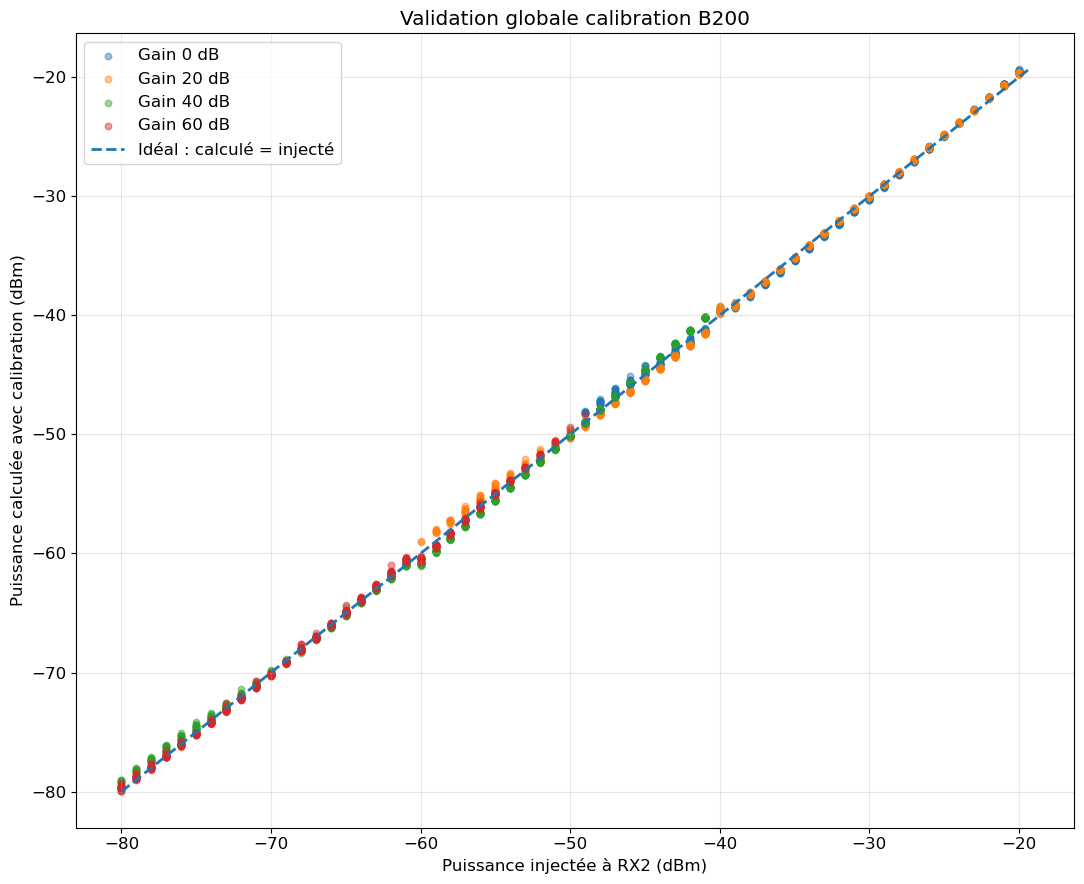

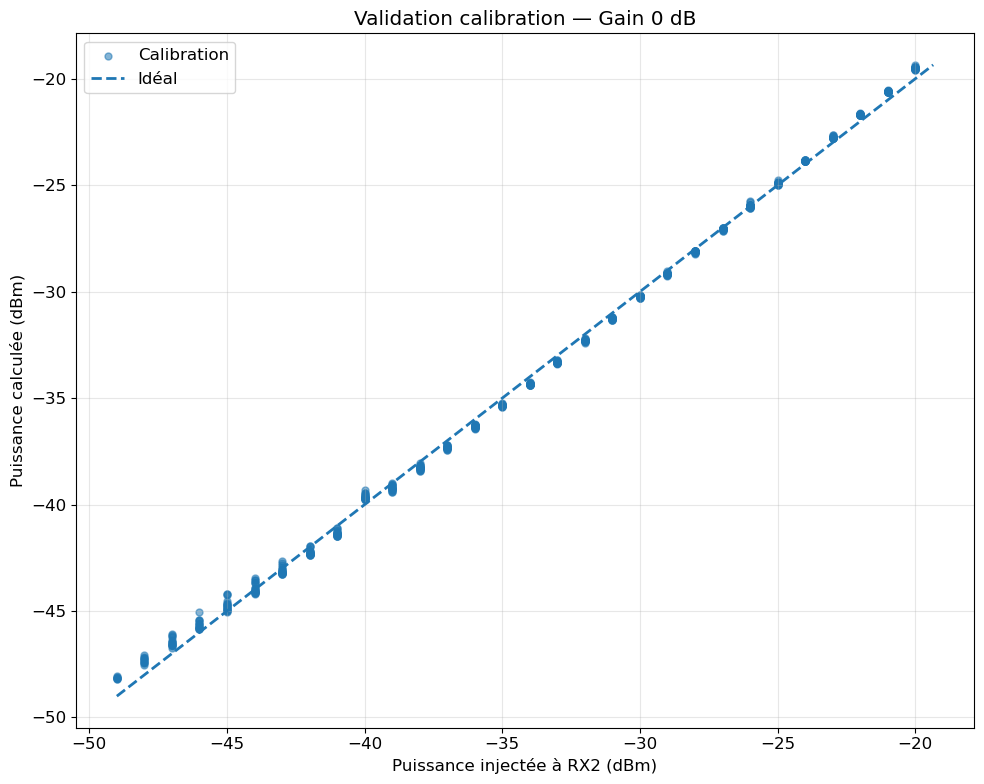

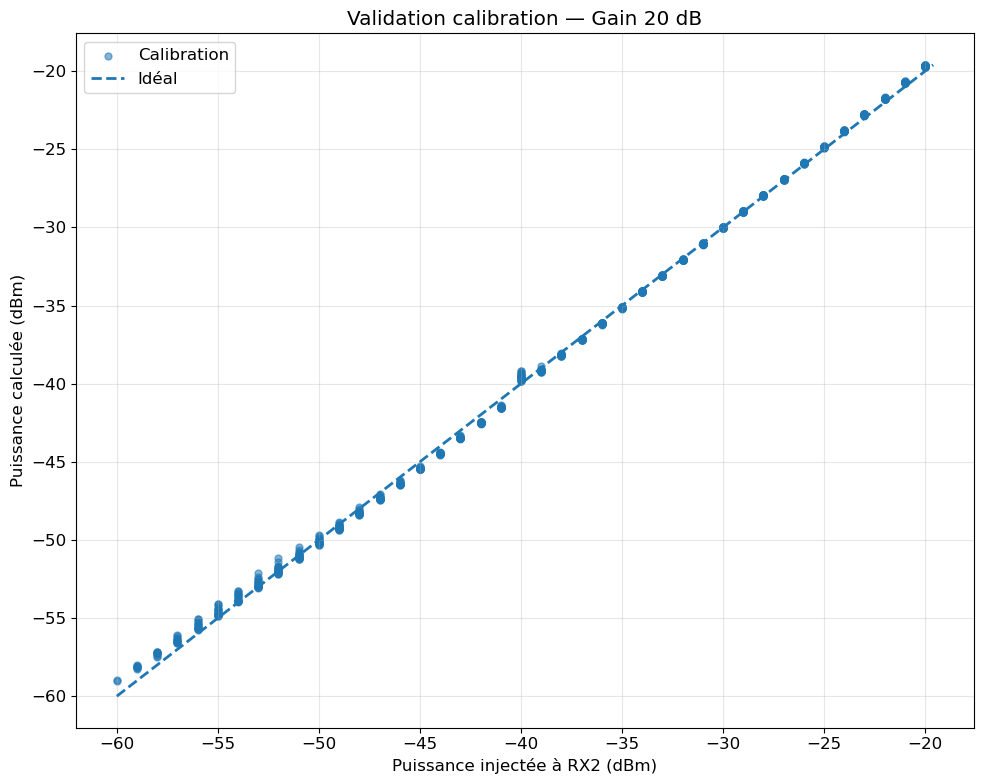

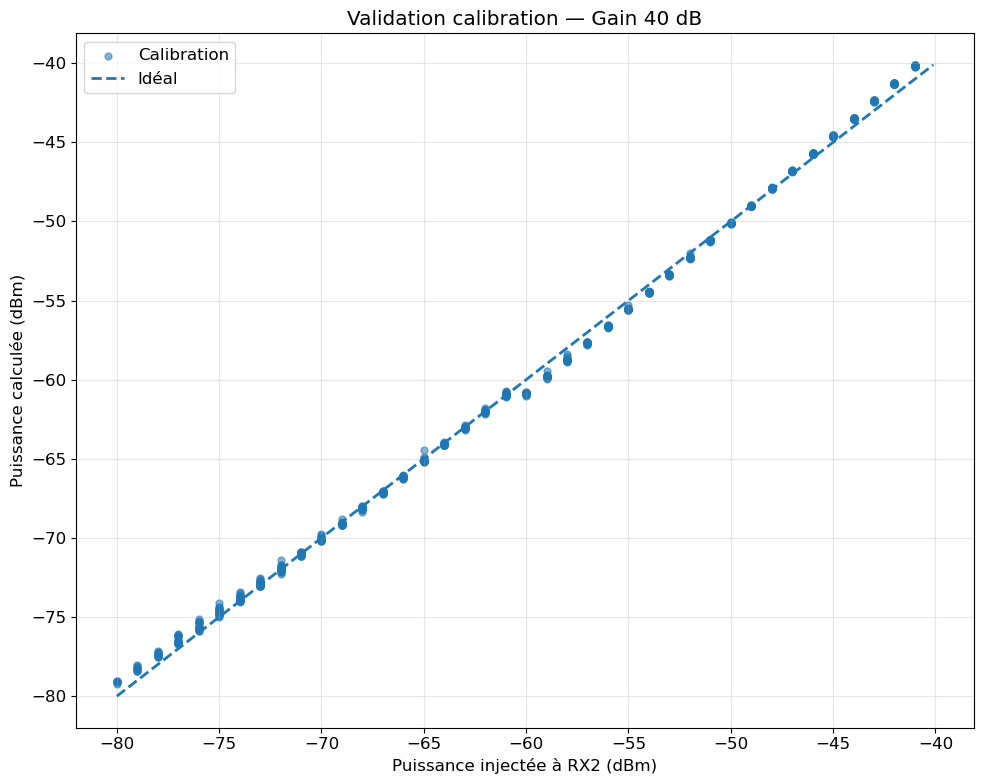

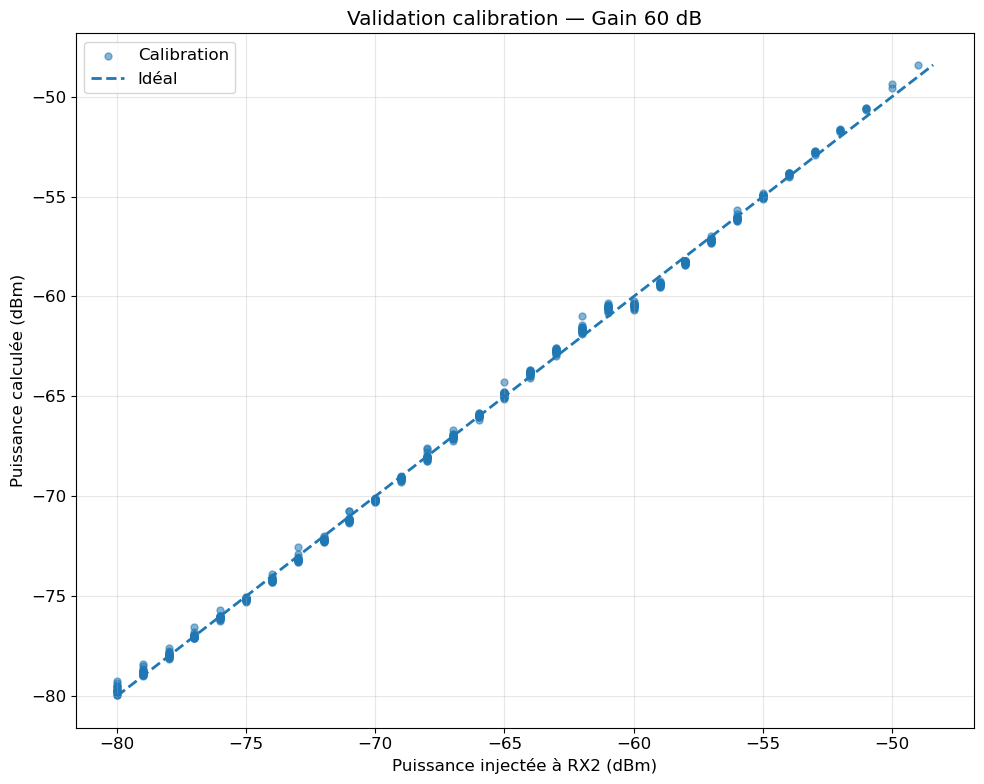

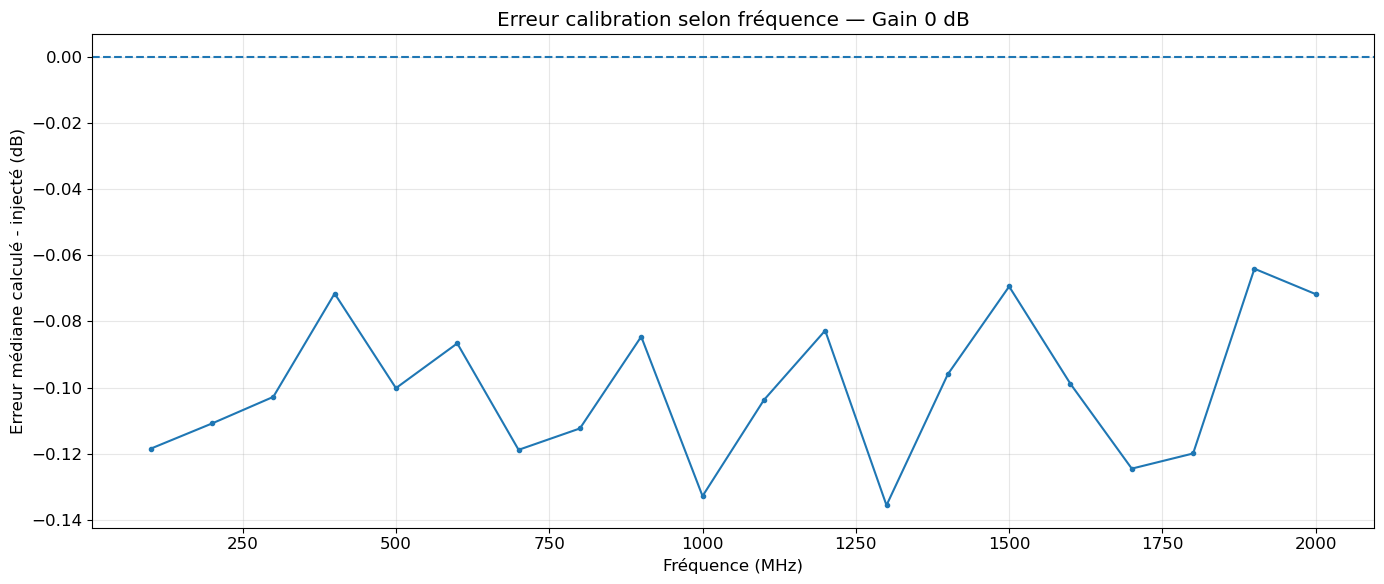

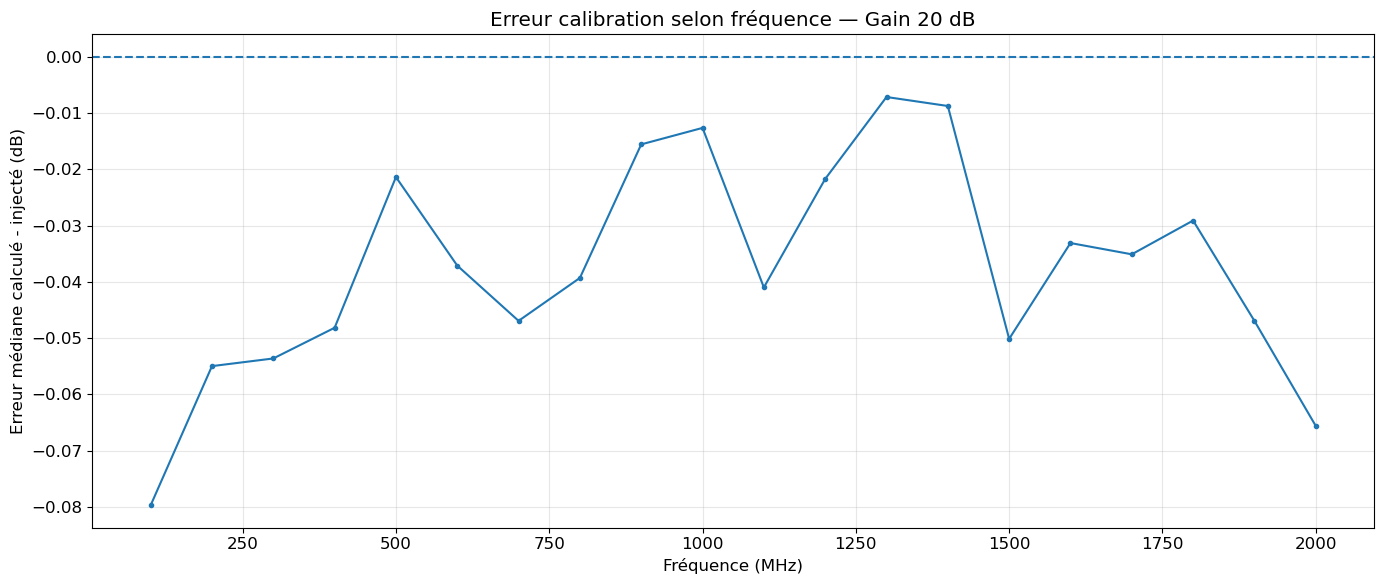

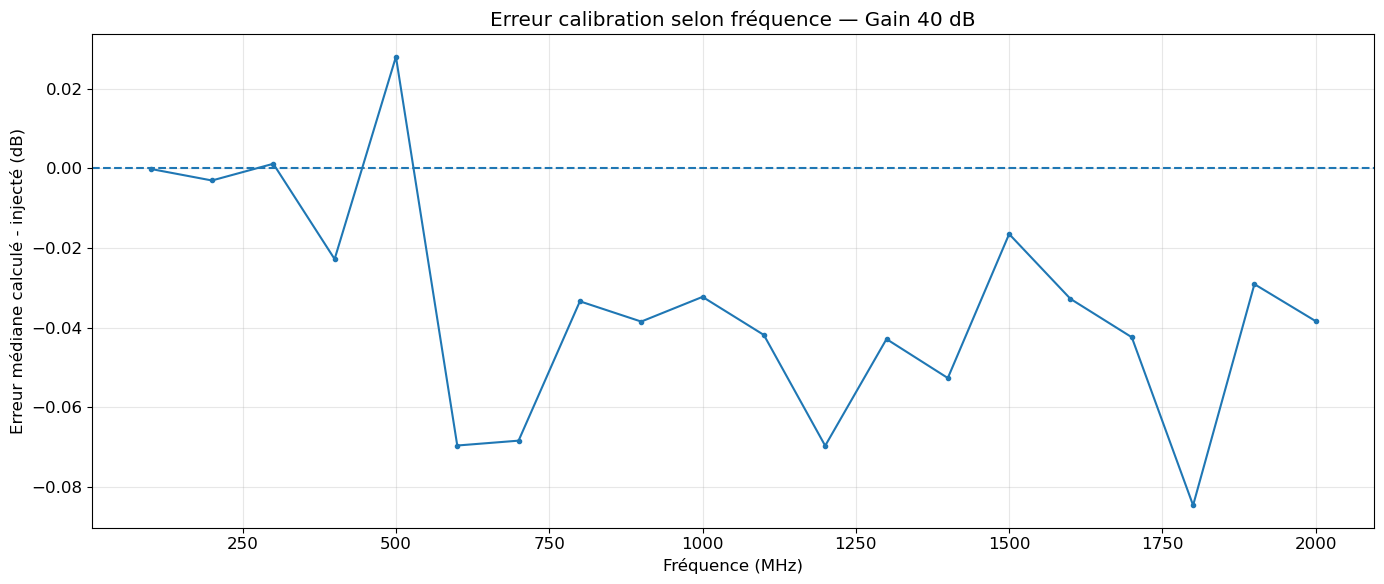

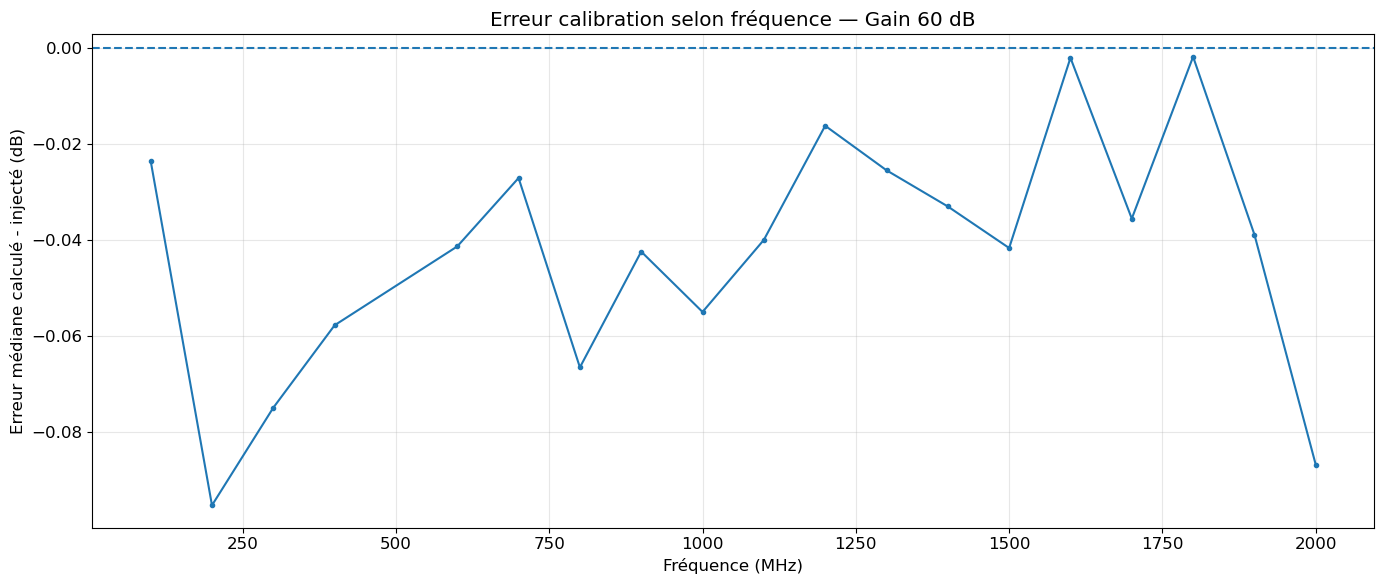


VARIABLES DISPONIBLES EN MÉMOIRE

calibration_table :
    calibration simple par fréquence/gain

models_table :
    slope + intercept + R² par fréquence/gain

summary_df :
    résumé de la qualité de calibration

validation_df :
    comparaison point par point entre injecté et calculé



In [13]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# 1) CONFIGURATION
# ============================================================

INPUT_CSV = Path(
    "/home/yousef/Documents/testing_scripts/GEVernova/"
    "Fi_Wo_Ca_Dy/Files/b200_dynamic_range_max_pulses/"
    "dynamic_range_linear_detailed_points.csv"
)

# Colonnes
FREQUENCY_COLUMN = "frequency_mhz"
GAIN_COLUMN = "gain_db"
INPUT_DBM_COLUMN = "input_rx2_dbm"

# IMPORTANT :
# colonne contenant le niveau BRUT mesuré en dBFS
DBFS_COLUMN = "max_dbfs"

# Colonne indiquant les points appartenant
# à la zone linéaire
LINEAR_COLUMN = "is_linear_final"

# Gains à utiliser
REQUESTED_GAINS_DB = [
    0.0,
    20.0,
    40.0,
    60.0,
    76.0,
]

# None = toute la plage disponible dans la base
MIN_FREQUENCY_MHZ = None
MAX_FREQUENCY_MHZ = None

# Critères qualité
MIN_POINTS_PER_CASE = 4
MIN_R2 = 0.995
MAX_SLOPE_ERROR = 0.15
MAX_MEDIAN_ABS_ERROR_DB = 1.0


# ============================================================
# 2) OUTILS
# ============================================================

def parse_bool_series(series):
    return (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "oui"])
    )


def load_data():

    if not INPUT_CSV.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {INPUT_CSV}"
        )

    df = pd.read_csv(INPUT_CSV)

    print("=" * 80)
    print("BASE DE DONNÉES")
    print("=" * 80)

    print("\nFichier :", INPUT_CSV)

    print("\nColonnes disponibles :")
    for column in df.columns:
        print(" -", column)

    required = [
        FREQUENCY_COLUMN,
        GAIN_COLUMN,
        INPUT_DBM_COLUMN,
        DBFS_COLUMN,
    ]

    missing = [
        column
        for column in required
        if column not in df.columns
    ]

    if missing:
        raise ValueError(
            "\nColonnes manquantes : "
            + ", ".join(missing)
            + "\n\n"
            + "Vérifie surtout DBFS_COLUMN."
        )

    # Conversion numérique
    for column in required:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    df = df.dropna(
        subset=required
    ).copy()

    # Conversion booléenne
    if LINEAR_COLUMN in df.columns:

        df[LINEAR_COLUMN] = (
            parse_bool_series(
                df[LINEAR_COLUMN]
            )
        )

    else:

        print(
            f"\nWARNING : '{LINEAR_COLUMN}' absente."
        )

        print(
            "Tous les points seront utilisés."
        )

        df[LINEAR_COLUMN] = True

    # Filtre fréquence
    if MIN_FREQUENCY_MHZ is not None:

        df = df[
            df[FREQUENCY_COLUMN]
            >= MIN_FREQUENCY_MHZ
        ]

    if MAX_FREQUENCY_MHZ is not None:

        df = df[
            df[FREQUENCY_COLUMN]
            <= MAX_FREQUENCY_MHZ
        ]

    # Filtre gains
    df = df[
        df[GAIN_COLUMN].apply(
            lambda value: any(
                np.isclose(
                    value,
                    gain,
                    atol=0.1,
                )
                for gain in REQUESTED_GAINS_DB
            )
        )
    ].copy()

    if df.empty:
        raise RuntimeError(
            "Aucune donnée disponible après filtrage."
        )

    return df


# ============================================================
# 3) CALIBRATION POUR UN COUPLE FREQUENCE / GAIN
# ============================================================

def fit_case(case_df):

    # On ne garde que la zone linéaire
    linear_df = case_df[
        case_df[LINEAR_COLUMN]
    ].copy()

    linear_df = linear_df.dropna(
        subset=[
            INPUT_DBM_COLUMN,
            DBFS_COLUMN,
        ]
    )

    if len(linear_df) < MIN_POINTS_PER_CASE:

        raise RuntimeError(
            f"Seulement {len(linear_df)} points linéaires"
        )

    # --------------------------------------------------------
    # X : puissance réellement injectée à RX2
    # Y : puissance numérique mesurée par SDR
    # --------------------------------------------------------

    x_dbm = linear_df[
        INPUT_DBM_COLUMN
    ].to_numpy(
        dtype=float
    )

    y_dbfs = linear_df[
        DBFS_COLUMN
    ].to_numpy(
        dtype=float
    )

    # ========================================================
    # Régression :
    #
    # dBFS = a * dBm + b
    # ========================================================

    slope, intercept = np.polyfit(
        x_dbm,
        y_dbfs,
        1,
    )

    predicted_dbfs = (
        slope * x_dbm
        + intercept
    )

    residual = (
        y_dbfs
        - predicted_dbfs
    )

    ss_res = float(
        np.sum(
            residual ** 2
        )
    )

    ss_tot = float(
        np.sum(
            (
                y_dbfs
                - np.mean(y_dbfs)
            ) ** 2
        )
    )

    if ss_tot > 0:

        r2 = (
            1.0
            - ss_res / ss_tot
        )

    else:

        r2 = 1.0

    # ========================================================
    # METHODE SIMPLE :
    #
    # dBm ≈ dBFS + reference
    #
    # reference = dBm injecté - dBFS
    # ========================================================

    reference_samples = (
        x_dbm
        - y_dbfs
    )

    reference_dbm = float(
        np.median(
            reference_samples
        )
    )

    calculated_simple_dbm = (
        y_dbfs
        + reference_dbm
    )

    simple_error = (
        calculated_simple_dbm
        - x_dbm
    )

    # ========================================================
    # MODELE COMPLET :
    #
    # dBFS = a*dBm + b
    #
    # donc :
    #
    # dBm = (dBFS - b) / a
    # ========================================================

    calculated_model_dbm = (
        y_dbfs
        - intercept
    ) / slope

    model_error = (
        calculated_model_dbm
        - x_dbm
    )

    # ========================================================
    # ERREURS
    # ========================================================

    median_error_simple = float(
        np.median(
            np.abs(
                simple_error
            )
        )
    )

    max_error_simple = float(
        np.max(
            np.abs(
                simple_error
            )
        )
    )

    median_error_model = float(
        np.median(
            np.abs(
                model_error
            )
        )
    )

    # ========================================================
    # VALIDITE
    # ========================================================

    valid = bool(
        len(linear_df)
        >= MIN_POINTS_PER_CASE

        and r2
        >= MIN_R2

        and abs(
            slope - 1.0
        )
        <= MAX_SLOPE_ERROR

        and median_error_simple
        <= MAX_MEDIAN_ABS_ERROR_DB
    )

    return {

        "linear_df":
            linear_df,

        "slope":
            float(slope),

        "intercept":
            float(intercept),

        "r2":
            float(r2),

        "reference_dbm":
            reference_dbm,

        "reference_0dbfs_from_model_dbm":
            float(
                -intercept / slope
            ),

        "median_abs_error_simple_db":
            median_error_simple,

        "max_abs_error_simple_db":
            max_error_simple,

        "median_abs_error_model_db":
            median_error_model,

        "n_points":
            int(
                len(linear_df)
            ),

        "valid":
            valid,
    }


# ============================================================
# 4) CHARGEMENT DES DONNEES
# ============================================================

df = load_data()

frequencies = sorted(
    df[
        FREQUENCY_COLUMN
    ].unique()
)

gains = sorted(
    df[
        GAIN_COLUMN
    ].unique()
)


print("\n" + "=" * 80)
print("CALIBRATION B200")
print("=" * 80)

print(
    "\nNombre total de points :",
    len(df)
)

print(
    "\nGains disponibles :",
    gains
)

print(
    f"\nNombre de fréquences : "
    f"{len(frequencies)}"
)

print(
    f"Plage : "
    f"{min(frequencies):.1f} MHz "
    f"-> {max(frequencies):.1f} MHz"
)


# ============================================================
# 5) CALCUL DE LA CALIBRATION
# ============================================================

# Tout reste uniquement en mémoire

calibration_table = {}

models_table = {}

summary_rows = []

validation_rows = []


grouped = df.groupby(
    [
        FREQUENCY_COLUMN,
        GAIN_COLUMN,
    ],
    sort=True,
)


for (
    frequency_mhz,
    gain_db,
), case_df in grouped:

    frequency_mhz = float(
        frequency_mhz
    )

    frequency_hz = (
        frequency_mhz
        * 1e6
    )

    gain_db = float(
        gain_db
    )

    try:

        result = fit_case(
            case_df
        )

    except RuntimeError as error:

        print(
            f"SKIP : "
            f"{frequency_mhz:.1f} MHz | "
            f"Gain {gain_db:.0f} dB | "
            f"{error}"
        )

        continue

    # --------------------------------------------------------
    # Référence simple
    # --------------------------------------------------------

    reference_dbm = (
        result[
            "reference_dbm"
        ]
    )

    calibration_table.setdefault(
        frequency_hz,
        {},
    )

    calibration_table[
        frequency_hz
    ][
        gain_db
    ] = reference_dbm

    # --------------------------------------------------------
    # Modèle complet
    # --------------------------------------------------------

    models_table.setdefault(
        frequency_hz,
        {},
    )

    models_table[
        frequency_hz
    ][
        gain_db
    ] = {

        "slope":
            result["slope"],

        "intercept":
            result["intercept"],

        "r2":
            result["r2"],

        "reference_dbm":
            reference_dbm,

        "valid":
            result["valid"],
    }

    # --------------------------------------------------------
    # Résumé
    # --------------------------------------------------------

    summary_rows.append({

        "frequency_mhz":
            frequency_mhz,

        "gain_db":
            gain_db,

        "n_linear_points":
            result[
                "n_points"
            ],

        "slope_dbfs_per_dbm":
            result[
                "slope"
            ],

        "intercept_dbfs":
            result[
                "intercept"
            ],

        "r2":
            result[
                "r2"
            ],

        "reference_dbm":
            reference_dbm,

        "median_abs_error_simple_db":
            result[
                "median_abs_error_simple_db"
            ],

        "max_abs_error_simple_db":
            result[
                "max_abs_error_simple_db"
            ],

        "median_abs_error_model_db":
            result[
                "median_abs_error_model_db"
            ],

        "valid":
            result[
                "valid"
            ],
    })

    # --------------------------------------------------------
    # Validation point par point
    # --------------------------------------------------------

    linear_df = (
        result[
            "linear_df"
        ]
    )

    for _, row in linear_df.iterrows():

        injected_dbm = float(
            row[
                INPUT_DBM_COLUMN
            ]
        )

        measured_dbfs = float(
            row[
                DBFS_COLUMN
            ]
        )

        # Conversion simple
        calculated_simple_dbm = (
            measured_dbfs
            + reference_dbm
        )

        # Conversion avec modèle complet
        calculated_model_dbm = (
            measured_dbfs
            - result[
                "intercept"
            ]
        ) / result[
            "slope"
        ]

        validation_rows.append({

            "frequency_mhz":
                frequency_mhz,

            "gain_db":
                gain_db,

            "injected_rx2_dbm":
                injected_dbm,

            "measured_dbfs":
                measured_dbfs,

            "calculated_simple_dbm":
                calculated_simple_dbm,

            "error_simple_db":
                calculated_simple_dbm
                - injected_dbm,

            "calculated_model_dbm":
                calculated_model_dbm,

            "error_model_db":
                calculated_model_dbm
                - injected_dbm,
        })


# ============================================================
# 6) DATAFRAMES
# ============================================================

summary_df = pd.DataFrame(
    summary_rows
)

validation_df = pd.DataFrame(
    validation_rows
)


if summary_df.empty:

    raise RuntimeError(
        "Aucune calibration générée."
    )


summary_df = (
    summary_df
    .sort_values(
        [
            "gain_db",
            "frequency_mhz",
        ]
    )
    .reset_index(
        drop=True
    )
)


validation_df = (
    validation_df
    .sort_values(
        [
            "gain_db",
            "frequency_mhz",
            "injected_rx2_dbm",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 7) QUALITE GLOBALE
# ============================================================

quality = (
    summary_df

    .groupby(
        "gain_db"
    )

    .agg(

        frequencies=(
            "valid",
            "size"
        ),

        valid_frequencies=(
            "valid",
            "sum"
        ),

        median_r2=(
            "r2",
            "median"
        ),

        median_simple_error_db=(
            "median_abs_error_simple_db",
            "median"
        ),

        median_model_error_db=(
            "median_abs_error_model_db",
            "median"
        ),

        max_simple_error_db=(
            "max_abs_error_simple_db",
            "max"
        ),
    )
)


print("\n" + "=" * 80)
print("RÉSULTAT CALIBRATION")
print("=" * 80)

print(
    "\nQualité globale par gain :"
)

display(
    quality
)


# ============================================================
# 8) TABLE COMPLETE
# ============================================================

print(
    "\nTable de calibration :"
)

display(

    summary_df[
        [
            "frequency_mhz",
            "gain_db",
            "n_linear_points",
            "slope_dbfs_per_dbm",
            "intercept_dbfs",
            "r2",
            "reference_dbm",
            "median_abs_error_simple_db",
            "median_abs_error_model_db",
            "valid",
        ]
    ]
)


# ============================================================
# 9) GRAPHE GLOBAL :
#    injecté vs calculé
# ============================================================

plt.figure(
    figsize=(11, 9)
)


for gain_db in sorted(
    validation_df[
        "gain_db"
    ].unique()
):

    gain_df = validation_df[
        np.isclose(
            validation_df[
                "gain_db"
            ],
            gain_db
        )
    ]

    plt.scatter(
        gain_df[
            "injected_rx2_dbm"
        ],
        gain_df[
            "calculated_model_dbm"
        ],
        s=22,
        alpha=0.45,
        label=(
            f"Gain {gain_db:.0f} dB"
        )
    )


minimum = min(
    validation_df[
        "injected_rx2_dbm"
    ].min(),

    validation_df[
        "calculated_model_dbm"
    ].min()
)


maximum = max(
    validation_df[
        "injected_rx2_dbm"
    ].max(),

    validation_df[
        "calculated_model_dbm"
    ].max()
)


plt.plot(
    [
        minimum,
        maximum
    ],
    [
        minimum,
        maximum
    ],
    "--",
    linewidth=2,
    label="Idéal : calculé = injecté"
)


plt.xlabel(
    "Puissance injectée à RX2 (dBm)"
)

plt.ylabel(
    "Puissance calculée avec calibration (dBm)"
)

plt.title(
    "Validation globale calibration B200"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 10) UN GRAPHE POUR CHAQUE GAIN
# ============================================================

for gain_db in sorted(
    validation_df[
        "gain_db"
    ].unique()
):

    gain_df = validation_df[
        np.isclose(
            validation_df[
                "gain_db"
            ],
            gain_db
        )
    ].copy()

    plt.figure(
        figsize=(10, 8)
    )

    plt.scatter(
        gain_df[
            "injected_rx2_dbm"
        ],
        gain_df[
            "calculated_model_dbm"
        ],
        s=25,
        alpha=0.55,
        label="Calibration"
    )


    minimum = min(
        gain_df[
            "injected_rx2_dbm"
        ].min(),

        gain_df[
            "calculated_model_dbm"
        ].min()
    )


    maximum = max(
        gain_df[
            "injected_rx2_dbm"
        ].max(),

        gain_df[
            "calculated_model_dbm"
        ].max()
    )


    plt.plot(
        [
            minimum,
            maximum
        ],
        [
            minimum,
            maximum
        ],
        "--",
        linewidth=2,
        label="Idéal"
    )


    plt.xlabel(
        "Puissance injectée à RX2 (dBm)"
    )

    plt.ylabel(
        "Puissance calculée (dBm)"
    )

    plt.title(
        f"Validation calibration — "
        f"Gain {gain_db:.0f} dB"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# 11) ERREUR SELON LA FREQUENCE
# ============================================================

for gain_db in sorted(
    validation_df[
        "gain_db"
    ].unique()
):

    gain_df = validation_df[
        np.isclose(
            validation_df[
                "gain_db"
            ],
            gain_db
        )
    ].copy()


    error_vs_frequency = (

        gain_df

        .groupby(
            "frequency_mhz",
            as_index=False
        )

        ["error_model_db"]

        .median()
    )


    plt.figure(
        figsize=(14, 6)
    )


    plt.plot(
        error_vs_frequency[
            "frequency_mhz"
        ],

        error_vs_frequency[
            "error_model_db"
        ],

        marker="o",
        markersize=3
    )


    plt.axhline(
        0,
        linestyle="--",
        linewidth=1.5
    )


    plt.xlabel(
        "Fréquence (MHz)"
    )

    plt.ylabel(
        "Erreur médiane calculé - injecté (dB)"
    )

    plt.title(
        f"Erreur calibration selon fréquence — "
        f"Gain {gain_db:.0f} dB"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 12) VARIABLES DISPONIBLES EN MEMOIRE
# ============================================================

print("\n" + "=" * 80)
print("VARIABLES DISPONIBLES EN MÉMOIRE")
print("=" * 80)

print("""
calibration_table :
    calibration simple par fréquence/gain

models_table :
    slope + intercept + R² par fréquence/gain

summary_df :
    résumé de la qualité de calibration

validation_df :
    comparaison point par point entre injecté et calculé
""")